# Previsione dell'affidabilità creditizia per il rilascio della carta di credito

Sei stato assunto dalla **Pro National Bank** come data scientist, e il tuo primo incarico consiste nel realizzare un modello in grado di **stimare l'affidabilità creditizia dei clienti**, al fine di aiutare il team dedicato a comprendere se accettare o meno la richiesta per il rilascio della carta di credito.

Ti vengono consegnati i dati anonimizzati di clienti che hanno già ottenuto la carta di credito e ne pagano regolarmente le rate. I dati sono disponibili in un file CSV che puoi scaricare da questo indirizzo:

credit_scoring.csv

Il file credit_scoring.csv contiene le informazioni dei correntisti che hanno richiesto l’apertura di una linea di credito.

Colonne del dataset:

- ID: numero identificativo del cliente
- CODE_GENDER: sesso del cliente
- FLAGOWNCAR: indicatore del possesso di un'automobile
- FLAGOWNREALTY: indicatore del possesso di una casa
- CNT_CHILDREN: numero di figli
- AMTINCOMETOTAL: reddito annuale
- NAMEINCOMETYPE: tipo di reddito
- NAMEEDUCATIONTYPE: livello di educazione
- NAMEFAMILYSTATUS: stato civile
- NAMEHOUSINGTYPE: tipo di abitazione
- DAYS_BIRTH: numero di giorni trascorsi dalla nascita
- DAYS_EMPLOYED: numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato)
- FLAG_MOBIL: indicatore della presenza di un numero di cellulare
- FLAGWORKPHONE: indicatore della presenza di un numero di telefono di lavoro
- FLAG_PHONE: indicatore della presenza di un numero di telefono
- FLAG_EMAIL: indicatore della presenza di un indirizzo email
- OCCUPATION_TYPE: tipo di occupazione
- CNT_FAM_MEMBERS: numero di familiari
- TARGET: variabile che vale 1 se il cliente ha una elevata affidabilità creditizia (pagamento costante delle rate), 0 altrimenti

**OBIETTIVO**:
Devi realizzare un modello che preveda il target dato, ovvero la variabile TARGET che indica se il cliente ha una buona affidabilità creditizia.

**PUNTO BONUS**: Se ad un cliente viene negata la carta di credito, il team deve essere in grado di fornirgli una motivazione. Questo significa che il tuo modello deve fornire delle indicazioni facilmente interpretabili.

### Importazione dei moduli

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import  classification_report, precision_score, recall_score, f1_score, accuracy_score, silhouette_score, make_scorer
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, export_graphviz
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from IPython.display import display, Markdown
import warnings

In [2]:
import os
import sys

graphviz_path = r"C:\Program Files\Graphviz\bin"
os.environ["PATH"] += os.pathsep + graphviz_path
import graphviz

### Definizione delle costanti

In [3]:
RANDOM_SEED = 0

### Importazione del dataset

In [4]:
# Importazione del dataset
raw_df = pd.read_csv("credit_scoring.csv")
raw_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,-11778.0,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
1,5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,-11777.0,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
2,5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,-21471.0,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-18489.0,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19093.0,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1


In [5]:
raw_df.shape

(338427, 19)

# Scelta dei modelli

Il problema da affrontare è una classificazione supervisionata binaria con variabile target 0/1, dove: 1 = cliente affidabile e 0 = cliente non affidabile.

Il dataset ha 338.427 righe e 19 colonne, quindi è abbastanza grande, e comprende: variabili numeriche, variabili categoriche e variabili binarie.

Si costruiranno e confronteranno i seguenti modelli di apprendimento supervisionato:
1. **Logistic Regression**, come baseline.
2. **Decision Tree**, molto interpretabile, utile affinchè il team sia in grado di fornire al cliente la motivazione per cui gli è stata negata la carta di credito.
3. **Random Forest**: un modello ensemble basato su alberi binari e bagging. Il bagging consiste nella costruzione e nell'addestramento in parallelo di molti alberi indipendenti. Questo consente di ridurre la varianza. La Random Forest funziona bene con dataset grandi, dati tabellari e variabili categoriche.
4. **Gradient Boosting**: un modello ensamble basato alberi decisionali e boosting. Il boosting consiste nella costruzione e nell'addestramento di alberi in sequenza, e ognuno corregge gli errori del precedente. Questo consente di ridurre la varianza e il bias (quindi la precisione), e catturare bene relazioni complesse tra le variabili. Con modelli di Gradient Boosting spesso l'accuratezza, ROC-AUC e F1-score migliorano. Lo svantaggio è che questo modello, non lavorando in parallelo ma in sequenza, è più lento da addestrare.

I seguenti modelli NON verranno utilizzati:
- KNN e SVM non verranno utilizzati perchè non sono adatti a dataset di grandi dimensioni come questo, in quanto presentano elevati costi computazionali e scarsa scalabilità. Inoltre, gestiscono male variabili categoriche.
- Naive Bayes non verrà utilizzato perchè assume che tutte le feature siano indipendenti tra loro dato il target: ipotesi non realistica nel contesto del credit scoring, dove molte variabili sono correlate. Ad esempio saranno correlate le variabili 'reddito' e 'tipo di lavoro' o le variabili 'età' e 'anni di lavoro'...

Le Reti Neurali potrebbero essere utilizzate, ma su dati tabellari sono meno adatte dei modelli basati sugli alberi decisionali, quindi è stato scelto di non usarle.

I modelli verrano confrontati tra loro utilizzando come metriche: Precision, Recall, F1-score, Confusion Matrix e ROC-AUC.

## 1. Data cleaning

In [6]:
# creo una copia del dataframe
df = raw_df.copy()

- **Gestione dei dati mancanti**

In [7]:
# Verifica che non ci siano dati mancanti
raw_df.isna().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          1
NAME_HOUSING_TYPE           1
DAYS_BIRTH                  1
DAYS_EMPLOYED               1
FLAG_MOBIL                  1
FLAG_WORK_PHONE             1
FLAG_PHONE                  1
FLAG_EMAIL                  1
OCCUPATION_TYPE        103342
CNT_FAM_MEMBERS             1
TARGET                      0
dtype: int64

Per le features con pochi NaN (in questo dataset ce ne sono alcune con 1 NaN) si procede alla rimozione dei NaN, poichè eliminare poche righe su 338427 non ha alcun impatto statistico.

Per la variabile *'tipo di occupazione'* invece i NaN sono un numero considerevole (103342): circa il 30% del dataset. Quindi i NaN di questa feature non possono essere elinimati perchè comporterbbero una perdita di quasi 1/3 del datset. Si sceglie quindi di creare la nuova categoria *"Unknown"* per i valori NaN.

In [8]:
# 1. variabile 'tipo di occupazione': i NaN vengono sostituiti da "Unknown"
df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Unknown")


# 2. Rimozione di NaN nelle colonne dove sono pochi: in questo caso abbiamo solo colonne con NaN = 1

# conta i NaN per colonna
nan_counts = df.isna().sum()

# seleziona le colonne con 1 NaN
cols_few_nan = nan_counts[nan_counts == 1].index

# elimina le righe con NaN in queste colonne
df = df.dropna(subset=cols_few_nan)


- **Gestione di valori infiniti**

In [9]:
# Verifica che non ci siano valori infiniti (positivi o negativi) nel dataframe
df.isin([np.inf, -np.inf]).sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
dtype: int64

Non ci sono valori infiniti.

- **Gestione dei duplicati** (dati un cliente inseriti più volte)

In [10]:
# verifica se ci sono righe identiche
df.duplicated().sum()

np.int64(0)

Non ci sono dati duplicati.

- **Tipi di dati**

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338426 non-null  int64  
 1   CODE_GENDER          338426 non-null  str    
 2   FLAG_OWN_CAR         338426 non-null  str    
 3   FLAG_OWN_REALTY      338426 non-null  str    
 4   CNT_CHILDREN         338426 non-null  int64  
 5   AMT_INCOME_TOTAL     338426 non-null  float64
 6   NAME_INCOME_TYPE     338426 non-null  str    
 7   NAME_EDUCATION_TYPE  338426 non-null  str    
 8   NAME_FAMILY_STATUS   338426 non-null  str    
 9   NAME_HOUSING_TYPE    338426 non-null  str    
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL           338426 

In [12]:
# conversione delle variabili 0/1 da float a interi
df['FLAG_MOBIL'] = df['FLAG_MOBIL'].astype(int)
df['FLAG_WORK_PHONE'] = df['FLAG_WORK_PHONE'].astype(int)
df['FLAG_PHONE'] = df['FLAG_PHONE'].astype(int)
df['FLAG_EMAIL'] = df['FLAG_EMAIL'].astype(int)
df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].astype(int)

- **Rimozione di feature inutili**

In [13]:
# Rimozione della feature 'ID'
df = df.drop("ID", axis=1)

#### Feature engineering

- **Individuazione di valori impossibili o fuori range**

In [14]:
# individuazione di valori anomali e outliers delle features numeriche
df[["CNT_CHILDREN", "AMT_INCOME_TOTAL", "DAYS_BIRTH", "DAYS_EMPLOYED", "CNT_FAM_MEMBERS"]].describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS
count,338426.000000,3.384260e+05,338426.000000,338426.000000,338426.000000
mean,0.428936,1.876689e+05,-15998.212897,60234.533869,2.197228
std,0.727991,1.107863e+05,4193.088539,138522.923248,0.899570
min,0.000000,2.554898e+04,-26636.000000,-17973.000000,1.000000
25%,0.000000,1.212306e+05,-19467.000000,-3116.000000,2.000000
50%,0.000000,1.628556e+05,-15623.000000,-1483.000000,2.000000
75%,1.000000,2.252082e+05,-12516.250000,-378.000000,3.000000
max,19.000000,7.071016e+06,-7566.000000,396498.000000,20.000000


La variabile *'DAYS_EMPLOYED'*, che indica il numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato), mostra due problemi principali:
- valori negativi e molto alti
- valori anomali molto alti

Analogamente anche la variabile *'DAYS_BIRTH'*, che indica il numero di giorni trascorsi dalla nascita presenta:
- valori negativi e molto alti

Di seguito si analizzano e si risolvono entrambi i problemi.

- **A. Gestione dei valori anomali di *'DAYS_EMPLOYED'***

Per la variabile *'DAYS_EMPLOYED'* il valore massimo è 396498 ≈ 1086 anni. Questo valore e altri valori molto alti, oviamente non realistici, sono valori placeholder/anomali usati per indicare clienti non occupati o pensionati. Questa situazione è tipica di dataset finanziari.
In generale i valori positivi di *'DAYS_EMPLOYED'* indicano un cliente disoccupato o pensionato. 

L'indicazione della fonte citata è quella di sostituire i valori placeholder/anomali con NaN.

--> fonte: https://medium.com/%40abdullahkbc/home-credit-default-risk-d88c6cfc7df1

Tuttavia modelli come Logistic Rgression, Decision Tree e Random Forest gestiscono male i NaN, quindi si è scelto di non usare questi valori. Inoltre sostituire i valori anomali con NaN, o con un altro valore, non permette di discriminare tra pensionati (che percepiscono un reddito) e studenti o persone che non hanno un lavoro (che non percepiscono reddito). La distinzione tra pensionati e disoccupati che non percepiscono reddito è però molto informativa per la previsione dell'affidabilità creditizia.

Fatte queste considerazioni, si procederebbe col creare una nuova feature che indica lo stato di occupazione facendo una distinzione tra occupati, pensionati, studenti/disoccupati.

Prima di procedere si analizza la composizione del dataset per capire quanti sono i disoccupati in generale e quanti appartengono a ogni categoria (pensionati/studennti/non occupati):

In [15]:
count_unemployed = (df["DAYS_EMPLOYED"] > 0).sum()
print(f"Il totale di non occupati (DAYS_EMPLOYED > 0) è {count_unemployed}")
perc_unemploted = ((df["DAYS_EMPLOYED"] > 0).mean() * 100).round(2)
print(f"La percentuale di non occupati (DAYS_EMPLOYED > 0) è {perc_unemploted} % del dataset")

Il totale di non occupati (DAYS_EMPLOYED > 0) è 57841
La percentuale di non occupati (DAYS_EMPLOYED > 0) è 17.09 % del dataset


In [16]:
df[df["DAYS_EMPLOYED"] > 0]["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Pensioner    57841
Name: count, dtype: int64

In [17]:
df["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 174365
Commercial associate     78090
Pensioner                57841
State servant            28113
Student                     17
Name: count, dtype: int64

L’analisi ha evidenziato che tutti i valori positivi di *'DAYS_EMPLOYED'* sono associati a clienti pensionati, indicando la presenza di un valore placeholder. Pertanto, si è scelto di convertire tutti i valori positivi di *'DAYS_EMPLOYED'* con zero.

In [18]:
# Conversione dei valori positivi di "DAYS_EMPLOYED" (tutti pensionati) con 0
df.loc[df["DAYS_EMPLOYED"] > 0, "DAYS_EMPLOYED"] = 0

- **B. Gestione dei valori negativi e molto alti di *'DAYS_EMPLOYED'* e *'DAYS_BIRTH'***

Le variabili *'numero di giorni trascorsi dalla nascita'* e *'numero di giorni trascorsi dalla data di assunzione'* sono valori negativi e molto alti, quindi poco interpretabili: vengono trasformate in anni e rappresentano *'età'* e *'anni di occupazione'*.

In [19]:
# creazione delle nuove feature
df["AGE"] = -df["DAYS_BIRTH"] / 365
df["YEARS_EMPLOYED"] = -df["DAYS_EMPLOYED"] / 365

# eliminazione delle vecchie feature
df = df.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"])

In [20]:
df[["AGE", "YEARS_EMPLOYED"]].describe().round(2)

,AGE,YEARS_EMPLOYED
count,338426.00,338426.00
mean,43.83,5.99
std,11.49,6.60
min,20.73,-0.00
25%,34.29,1.04
50%,42.80,4.06
75%,53.33,8.54
max,72.98,49.24


## 2. Analisi esplorativa delle variabili

### 2.1. Analisi della distribuzione della variabile target

La variabile target riguarda l'affidabilità creditizia dei clienti:
- vale 1 se il cliente ha una elevata affidabilità creditizia
- vale 0 se il cliente ha una bassa affidabilità creditizia

Frequenze assolute
TARGET
0    308704
1     29722
Name: count, dtype: int64
Frequenze relative
TARGET
0    91.217578
1     8.782422
Name: proportion, dtype: float64


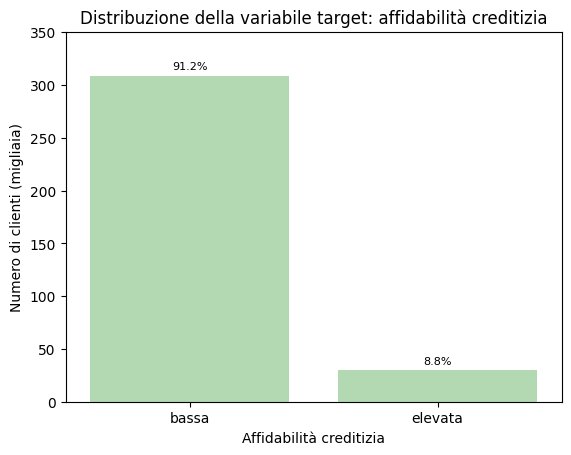

In [21]:
# distribuzione di frequenze
print("Frequenze assolute")
fa = df['TARGET'].value_counts()
print(fa)
print("Frequenze relative")
fr = df['TARGET'].value_counts(normalize=True) * 100
print(fr)

# Grafico a barre
plot = sns.countplot(x='TARGET', data=df, color='#addfad')
plt.title('Distribuzione della variabile target: affidabilità creditizia')
plt.xlabel('Affidabilità creditizia')
plt.ylabel('Numero di clienti (migliaia)')

# etichette asse x
plot.set_xticks([0, 1])
plot.set_xticklabels(['bassa', 'elevata'])

# etichette asse y
y_ticks = plot.get_yticks()
plot.set_yticks(y_ticks)
plot.set_yticklabels((y_ticks / 1000).astype(int))

# percentuali sopra le barre

total = len(df)

for p in plot.patches:
    height = p.get_height()
    plot.annotate(f"{height/total*100:.1f}%",
                  (p.get_x() + p.get_width() / 2., height),
                  ha='center', 
                  va='bottom',
                  fontsize=8,
                  xytext=(0, 3),
                  textcoords='offset points')

plt.show()

La distribuzione della variabile target 'Affidabilità creditizia' risulta **fortemente sbilanciata**: la maggior parte dei clienti (91.2%) ha una bassa affidabilità creditizia.

Gestire correttamente lo sbilanciamento delle classi è cruciale per evitare che i modelli abbiano un alto tasso di falsi negativi, migliorando così la precisione del cross-sell.

Per gestire lo sbilanciamento delle classi si utilizzerà la tecnica di penalizzazione della classe più frequente nel modello (*'Class Weights'*). Questo impone un costo aggiuntivo al modello per errori di classificazione sulla classe di minoranza durante l'addestramento.

### 2.2. Analisi della relazione tra ogni variabile e la variabile target

variabili categoriche vs target binario --> barplot

variabili continue vs target categorico --> boxplot e violinplot

In [22]:
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2,0,32.268493,12.158904
1,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2,0,32.265753,12.216438
2,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2,0,58.824658,3.134247
3,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1,1,50.654795,8.553425
4,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1,1,52.309589,8.410959


In [23]:
# Raggruppamento delle variabili per lo studio della relazione tra variabili
categorical_variables = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "CNT_CHILDREN", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", 
                         "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "OCCUPATION_TYPE", "CNT_FAM_MEMBERS"]
continuous_variables = ["AMT_INCOME_TOTAL", "AGE", "YEARS_EMPLOYED"]

In [24]:
# Mappatura nomi colonne
col_labels = {
    "CODE_GENDER": "Gender",
    "FLAG_OWN_CAR": "Owns Car",
    "FLAG_OWN_REALTY": "Owns Realty",
    "CNT_CHILDREN": "Counting Children",
    "NAME_INCOME_TYPE": "Income Type",
    "NAME_EDUCATION_TYPE": "Education Type",
    "NAME_FAMILY_STATUS": "Family Status",
    "NAME_HOUSING_TYPE": "Housing Type", 
    "FLAG_MOBIL": "Owns Mobile Phone", 
    "FLAG_WORK_PHONE": "Owns Work Phone",
    "FLAG_PHONE": "Owns Phone", 
    "FLAG_EMAIL": "Owns Email", 
    "OCCUPATION_TYPE": "Occupation Type", 
    "CNT_FAM_MEMBERS": "Counting Family Members",
    "AMT_INCOME_TOTAL": "Annual Income",
    "AGE": "Age", 
    "YEARS_EMPLOYED": "Years Employed (Employed Customers only)",
}

# Mappatura valori delle categorie
value_labels = {
    "M" : "Male",
    "F" : "Female",
    "Y" : "Yes",
    "N" : "No",
    1 : "Yes",
    0 : "No"

}

In [25]:
def plot_categorical_vs_response(var, col_labels=None, value_labels=None):
    """
    Barplot del tasso di elevata affidabilità creditizia per una variabile categorica.
    Mostra sopra le barre le percentuali di TARGET = 1.

   Args:
    - var: variabile categorica (nome colonna)
    - col_labels: dict, opzionale, mappatura {nome_colonna: nome_legibile}
    - value_labels: dict, opzionale, mappatura {valore_originale: valore_legibile}
    """

    # copia del dataframe
    df_plot = df.copy()

    # 1. TRASFORMAZIONE DELLE VARIABILI CON CATEGORIE POCO RAPPRESENTATE

    # trasformazione della variabile 'Counting Children' in 3 categorie
    if var == "CNT_CHILDREN":
        df_plot[var] = df_plot[var].apply(
            lambda x: "0 children" if x == 0
            else "1 child" if x == 1
            else "≥2 children"
        )
        value_map = None  # non serve mappatura perché abbiamo già i nomi leggibili

    # trasformazione della variabile 'Counting Family Members' in 3 categorie
    elif var == "CNT_FAM_MEMBERS":
        df_plot[var] = df_plot[var].apply(
            lambda x: "1–2 members" if x <= 2
            else "3–4 members" if x <= 4
            else "≥5 members"
        )
        value_map = None

    else:
        value_map = value_labels  # si usano le etichette specificate in value_labels

    
    # 2. CALCOLO DELLE STATISTICHE
    
    grouped = df_plot.groupby(var)['TARGET'].agg(['mean', 'count'])
    grouped = grouped.rename(columns={
        'mean': 'TARGET_rate',
        'count': 'n_total'
    }).sort_values(by='TARGET_rate', ascending=False)

    
    # 3. CREAZIONE DEL BARPLOT

    # mappatura dei valori se fornita
    if value_map:
        grouped = grouped.rename(index=value_map)

    # grafico a barre
    plt.figure(figsize=(max(8, len(grouped)*0.4), 6))
    ax = sns.barplot(x=grouped.index, y=grouped['TARGET_rate'], color='#addfad')

    # percentuali sopra le barre
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,  # posizione x al centro della barra
            height + 0.02,                 # posizione y leggermente sopra la barra
            f"{height*100:.1f}%",          # testo percentuale
            ha='center', fontsize=8
        )

    # Titolo leggibile
    title = col_labels[var] if col_labels and var in col_labels else var
    plt.title(f"{title} vs Credit Reliability")
 
    plt.xlabel(title)
    plt.ylabel("Tasso elevata affidabilità creditizia")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, fontsize=8)

    plt.tight_layout()
    plt.show()

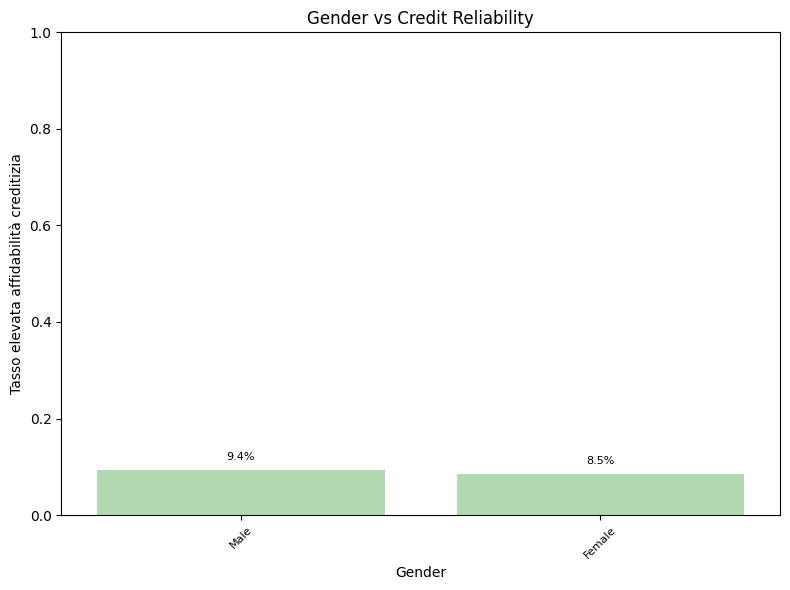

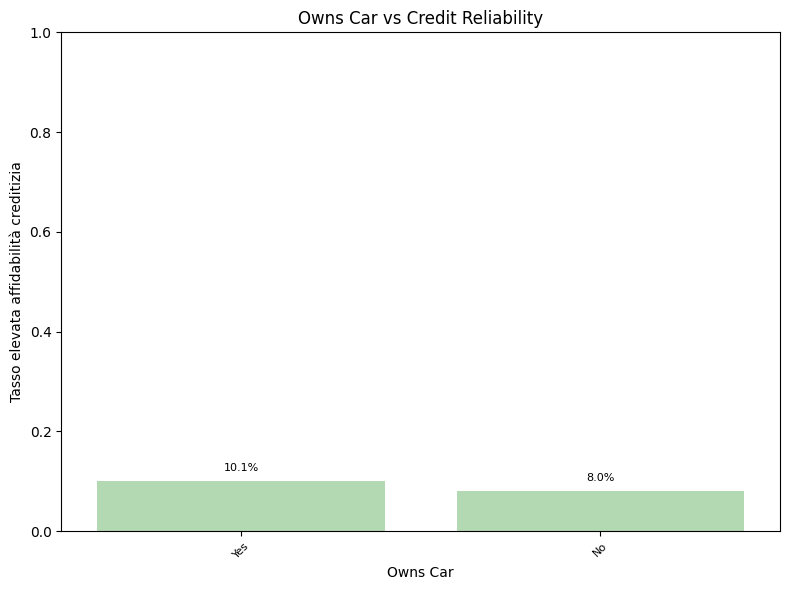

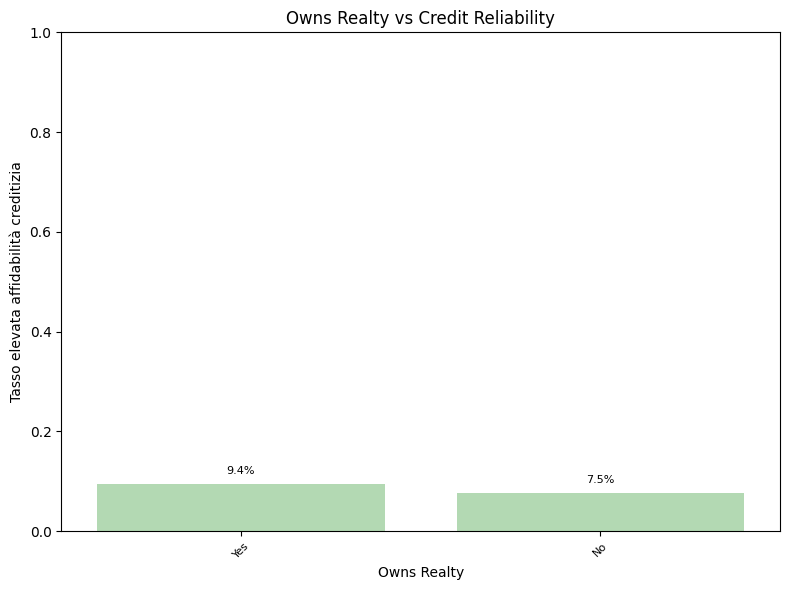

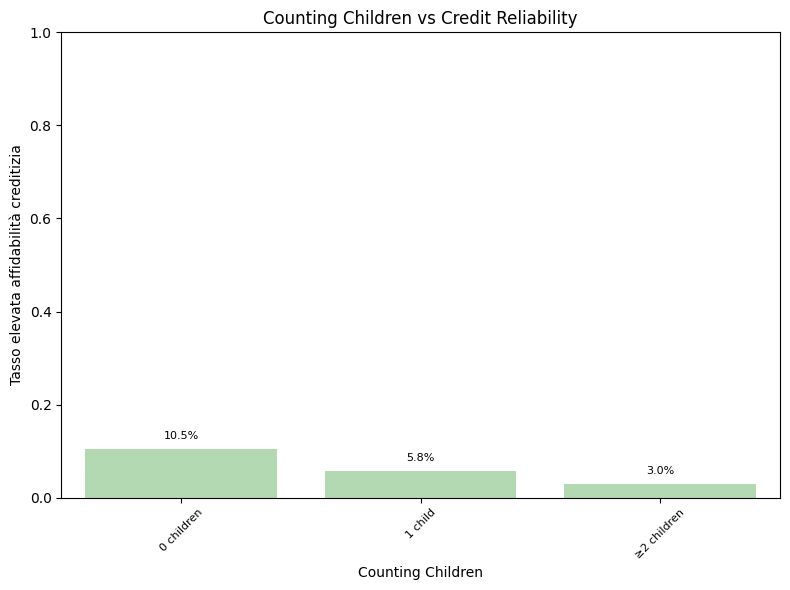

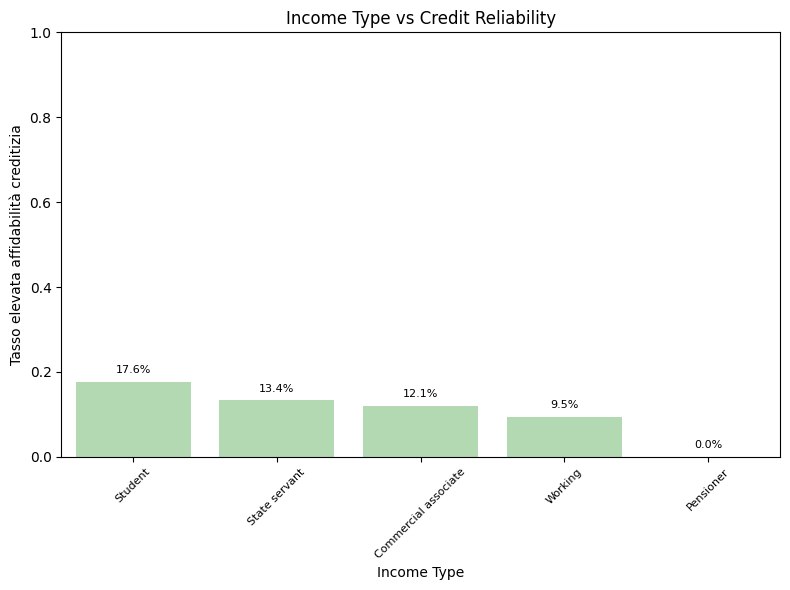

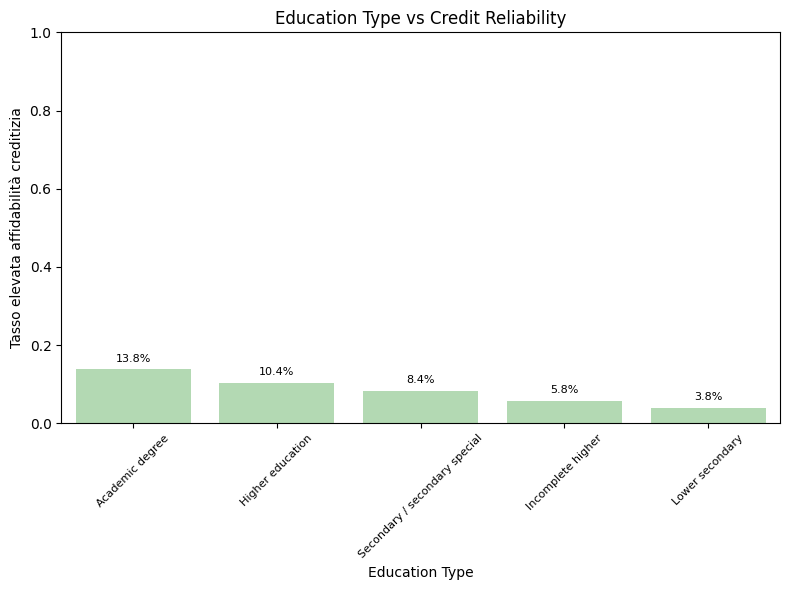

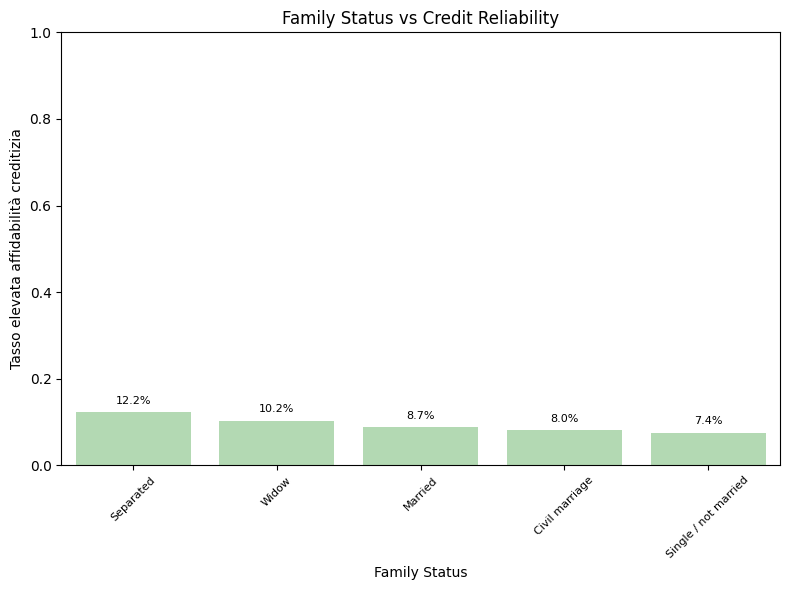

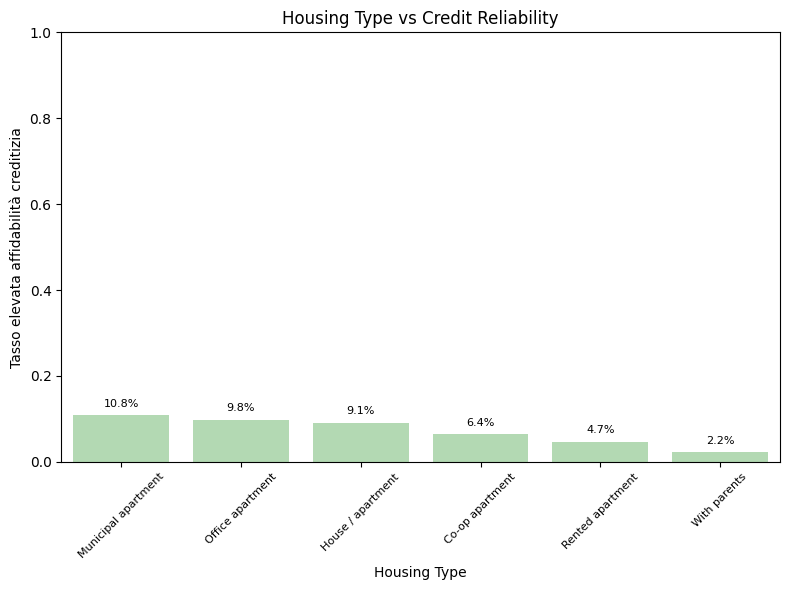

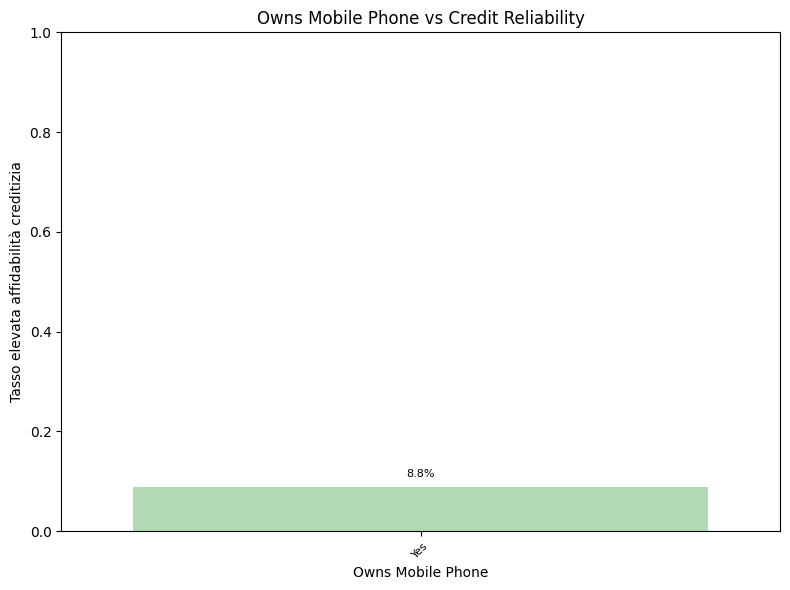

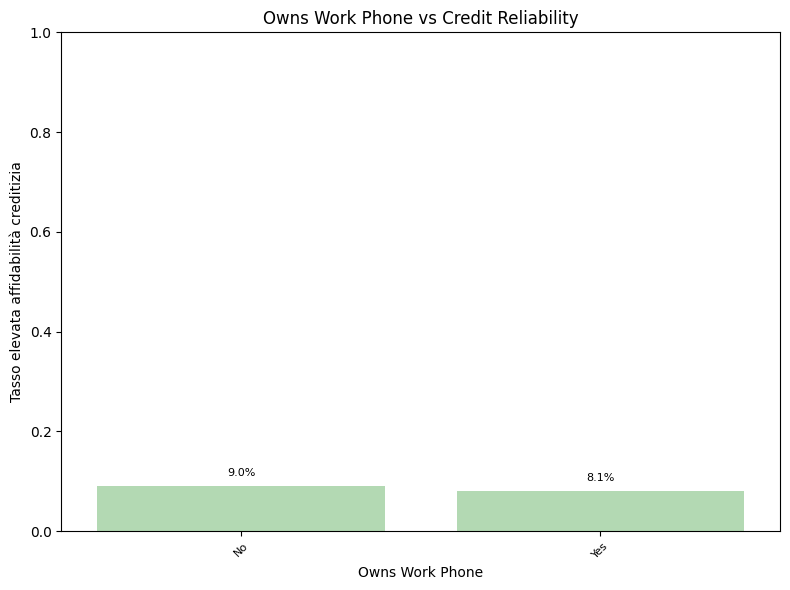

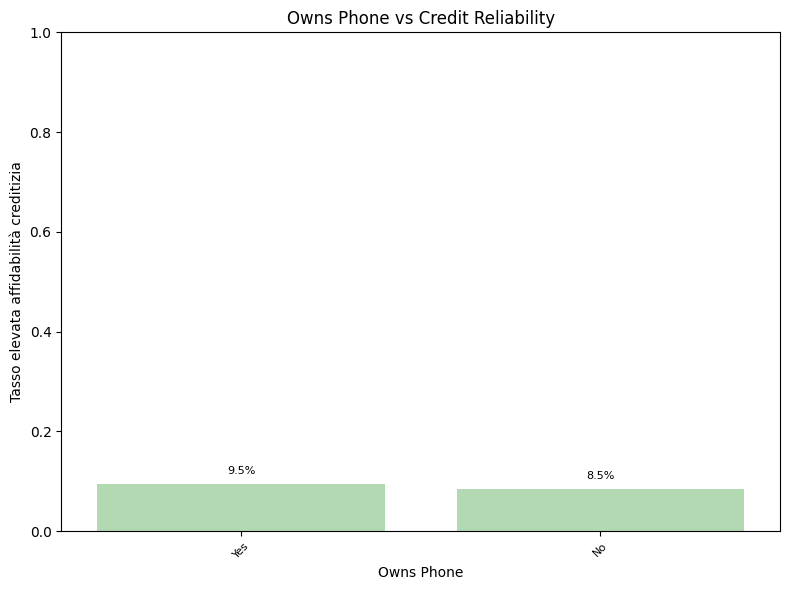

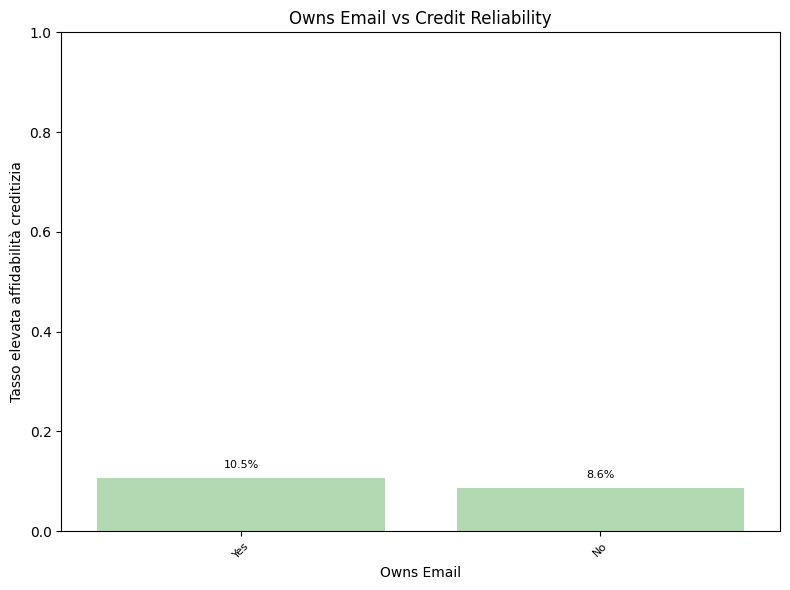

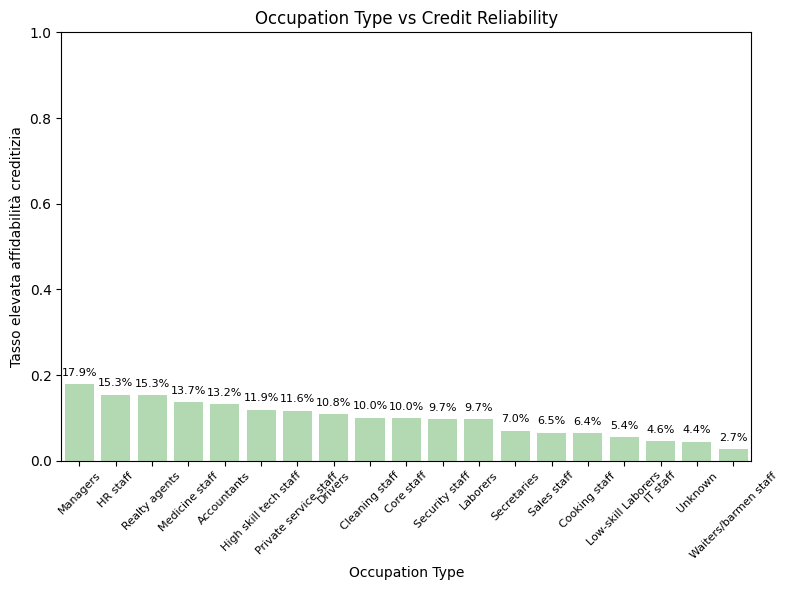

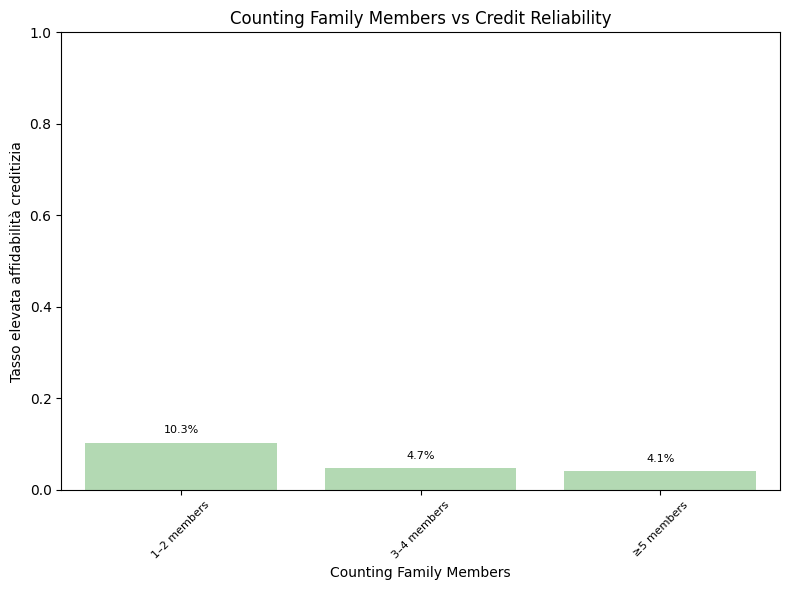

In [26]:
for var in categorical_variables:
    plot_categorical_vs_response(var, col_labels=col_labels, value_labels=value_labels)

In [27]:
# Funzione per analizzare la relazione tra ogni variabile continua e 'Response'

def plot_continuous_vs_response(var, col_labels=None, value_labels=None):
    """
    Boxplot + Violin plot di una variabile continua rispetto alla variabile target,
    con scala log per Annual_Premium e statistiche descrittive.

    Gestione speciale di Years Employed:
    - I valori 0 diventano NaN solo per la visualizzazione

    Args:
    - var: nome della colonna da plottare
    - col_labels: dizionario per rinominare colonne
    - value_labels: dizionario per rinominare valori categoriali
    """

    # copia del dataframe per evitare modifiche
    df_plot = df.copy()

    # nome leggibile della variabile
    var_label = col_labels.get(var, var) if col_labels else var
    

    # Gestione di 'Years Employed': sostituzione di  0 con NaN solo per la visualizzazione
    if var == "YEARS_EMPLOYED":
        df_plot['YEARS_EMPLOYED_plot'] = df_plot[var].replace(0, np.nan)
        plot_col = 'YEARS_EMPLOYED_plot'
    else:
        plot_col = var
        

    # divisione dello spazio grafico in 2
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    
    # 1. BOXPLOT  
    
    sns.boxplot(x='TARGET',
                y=plot_col,
                data=df_plot,
                color='#addfad',
                ax=axes[0],
                showfliers=False)
    
    axes[0].set_title(f"{var_label} vs Credit Reliability (Boxplot)")
    axes[0].set_xlabel("Credit Reliability")
    axes[0].set_ylabel(var_label)


    # Scala logaritmica solo per reddito
    if var == "AMT_INCOME_TOTAL":
        axes[0].set_yscale("log")

    # etichette target
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(["Low", "High"])


    # 2. VIOLIN PLOT
    
    sns.violinplot(x="TARGET",
                   y=plot_col,
                   data=df_plot,
                   color="#addfad",
                   inner="quartile",
                   ax=axes[1])
    
    axes[1].set_title(f"{var_label} vs Credit Reliability (Violin plot)")
    axes[1].set_xlabel("Credit Reliability")
    axes[1].set_ylabel(var_label)

    # Scala logaritmica solo per Annual_Premium
    if var == "AMT_INCOME_TOTAL":
        axes[1].set_yscale("log")

    # etichette target
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(["Low", "High"])


    # Mostra i grafici
    plt.tight_layout()
    plt.show()

    
    # 3. STATISTICHE NUMERICHE
    stats = (df.groupby("TARGET")[var]
             .agg(["mean", "median"])
             .rename(columns={"mean": "Mean", "median": "Median"}))

    # Mostra le statistiche
    display(stats)

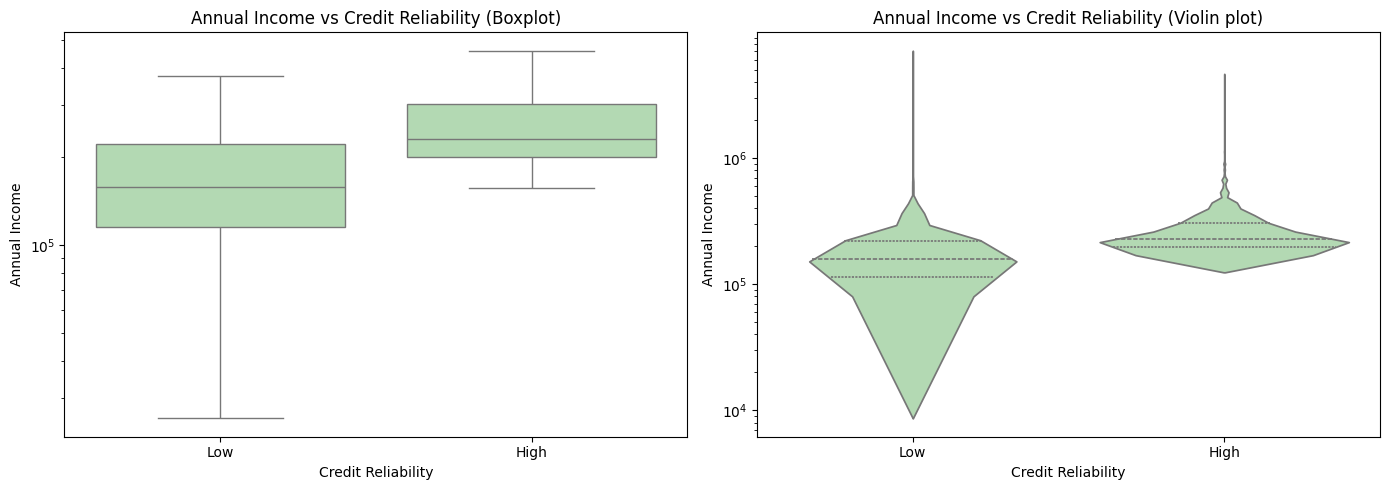

,Mean,Median
TARGET,,
0,179957.772681,157687.120
1,267759.590448,228884.475


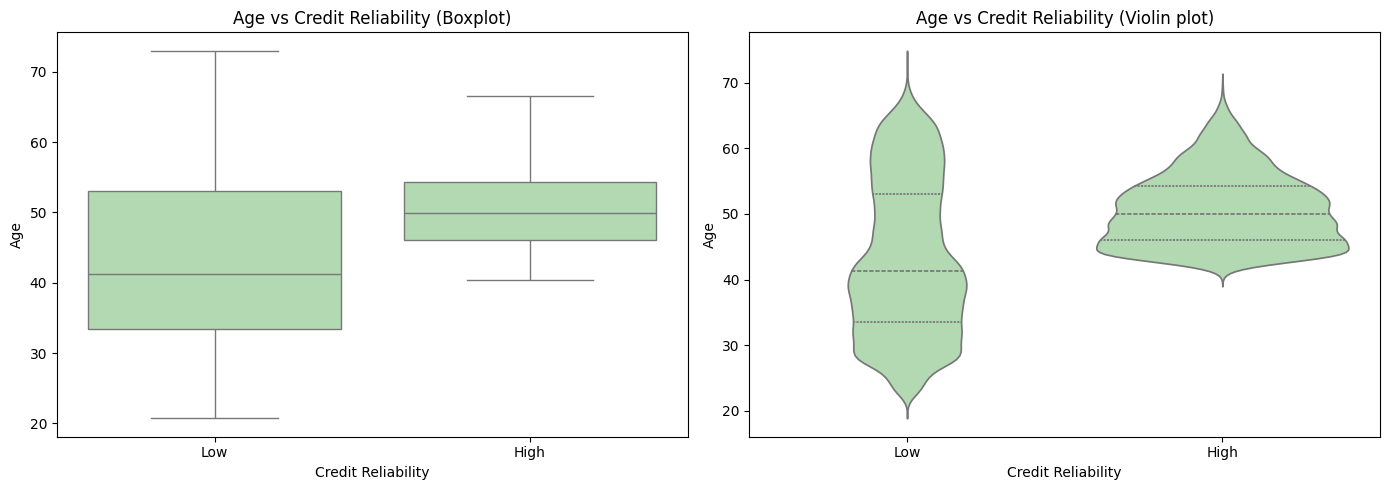

,Mean,Median
TARGET,,
0,43.174756,41.309589
1,50.643814,49.968493


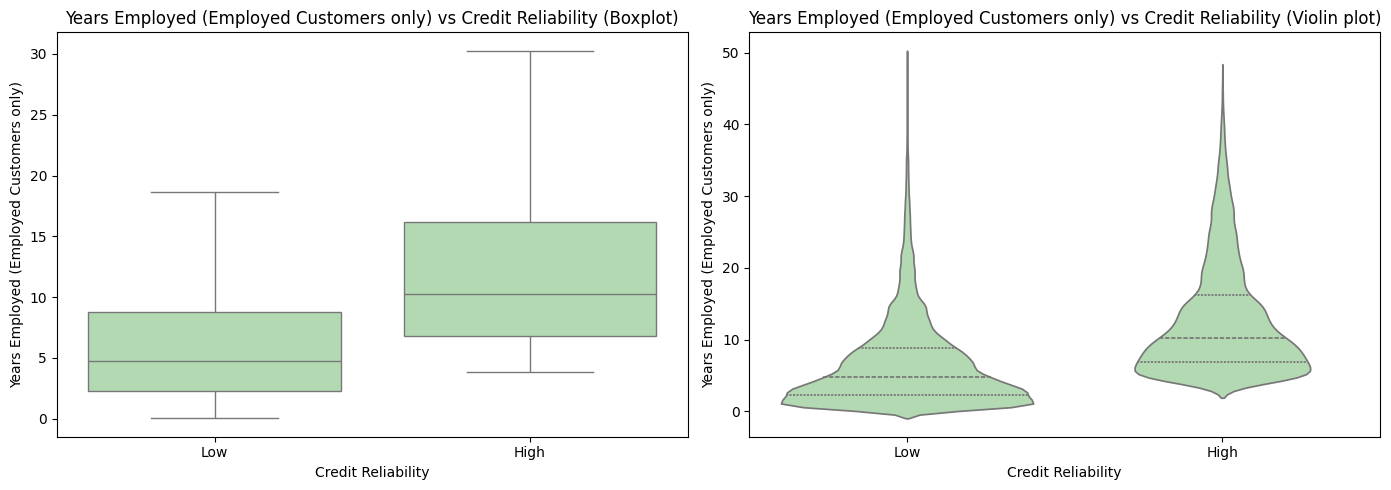

,Mean,Median
TARGET,,
0,5.339431,3.452055
1,12.723719,10.263014


In [28]:
for var in continuous_variables:
    plot_continuous_vs_response(var, col_labels, value_labels)

### Interprtazione dei risultati - variabili categoriche

I grafici mostrano la probabilità di affidabilità creditizia (TARGET =1) per le categorie di ogni variabile, cioè permettono di visualizzare quanto ogni variabile influenza la probabilità di affidabilità creditizia. Una variabile è informativa quando il tasso di affidabilità creditizia è diverso tra le categorie.

Analizzando i grafici è anche possibile determinare quali variabili presentano pochi dati in alcune categorie e quindi quando conviene raggrupparle.

**1. Variabili fortemente informative**

- **Income Type vs Credit Reliability** _ Si osserva che il tipo di reddito riflette la stabilità lavorativa, che è cruciale nel rischio creditizio.

- **Occupation Type vs Credit Reliability** _ Si nota che il tasso di affidabilità creditizia ha una variabilità ampia nei diversi tipi di lavoro (da ≈18% a ≈3%). Questo avvalora l'ipotesi che la professione sia fortemente legata al reddito, alla stabilità economica, e quindi all'affidabilità creditizia.

- **Education Type vs Credit Reliability** _ Si osserva che spesso ad una istruzione di grado superiore corrisponde una affidabilità maggiore. Il tipo di istruzione può essere correlato con la stabilità lavorativa o con il reddito

- **Counting Children vs Credit Reliability** _ Con questa variabile il grafico mostrerebbe instabilità statistica per categorie rare: infatti la maggior parte dei clienti ha 0 o 1 figlio, e alcune categorie estreme (5, 6 ecc.) hanno tassi molto alti ma campioni minuscoli. Di seguito sono mostrate le frequenze assolute di ogni classe'.

In [29]:
raw_df["CNT_CHILDREN"].value_counts()

CNT_CHILDREN
0     234631
1      67922
2      31117
3       4252
4        367
5        120
9          4
12         4
6          4
14         3
7          2
19         1
Name: count, dtype: int64

Per mostrare un grafico più interpretabile la variabile *'Counting Children'* è stata trasformata in una variabile a 3 categorie: *'0 figli'*, *'1 figlio'* e *'2 o più figli'*. Questo permette di eliminare le categorie rare e rendere il grafico più stabile.

Una volta trasformata la variabile *'Counting Children'*, si osserva che il numero di figli mostra una chiara correlazione negativa con l'affidabilità creditizia. I clienti senza figli presentano il tasso di affidabilità più elevato (10,5%), che scende al 5,8% per i clienti con un figlio e al 3,0% per quelli con due o più figli.
Questo andamento monotono suggerisce che l'aumento delle responsabilità familiari può ridurre la capacità finanziaria di far fronte agli obblighi di credito.

NOTA. La trasformazione della variabile *Counting Children*, non solo migliora il grafico ma migliora anche il modello di Regressione Logistica che verrà costruito, quindi la trasformazione verrà eseguita anche nel preprocessamento dei dati per quel modello, seguita da One-Hot Encoding.
Per il modello Random Forest invece verrà usata la variabile originale, poichè questo è un tipo di modello che esegue split automatici raggruppando autonomamente i dati in modo opportuno, e ignora le categorie poco informative.

- **Counting Family Members vs Credit Reliability** _ Analogamente alla variabile *'Counting Children'*, anche con questa variabile il grafico mostrerebbe instabilità statistica per categorie rare. Quindi è stata trasformata in una variabile a 3 categorie (*'1-2 membri'*, *'3-4 membri'* e *'5 o più membri'*), permettendo di eliminare le categorie rare e rendere il grafico più stabile e interpretabile. Di seguito sono mostrate le frequenze assolute di ogni classe.

In [30]:
raw_df["CNT_FAM_MEMBERS"].value_counts()

CNT_FAM_MEMBERS
2.0     180706
1.0      64896
3.0      59148
4.0      29236
5.0       3955
6.0        356
7.0        111
11.0         4
14.0         4
8.0          4
15.0         3
9.0          2
20.0         1
Name: count, dtype: int64

**2. Variabili moderatamente informative**

- **Family Status vs Credit Reliability** _ Non mostra una decisa discriminazione tra le categorie (Separated ≈ 12%, Widow ≈ 10%, Married ≈ 9%, Civil marriage ≈ 8%, Single ≈ 8%). La viabile è debolmente-moderatamente informativa.

- **Housing Type vs Credit Reliability** _ Mostra differenze moderate tra le categorie (Municipal apartment ≈ 11%, Office apartament ≈ 10%, House/apartment ≈ 9%, Co-op apartament ≈ 6%, Rented apartment ≈ 15, With parents ≈ 2%)


**3. Variabili debolmente informative** 

- **Gender vs Credit Reliability**: maschi ≈ 8.8% e femmine ≈ 8.7%.
- **Owns Car vs Credit Reliability**: clienti che non possiedono un'auto ≈ 9%, e clienti che la possiedono ≈ ~8%.
- **Owns Realty vs Credit Reliability**: clienti che non possiedono un immobile ≈ 9%, e clienti che lo possiedono ≈ ~8%.
- **Owns Work Phone vs Credit Reliability**: clienti che non possiedono un telefono di lavoro ~9% e clienti che lo possiedono ~8%.
- **Owns Phone vs Credit Reliability**: clienti che non possiedono un telefono = 8.5% e clienti che lo possiedono = 9.5%.
- **Owns Email vs Credit Reliability**: clienti che non possiedono una email = 8.6% e clienti che la possiedono = 10.5%.


**4. Variabili irrilevanti** 
- **Owns Mobile Phone vs Credit Reliability** non ha **nessun valore informativo** poichè tutti i clienti possiedono un cellulare. La variabile **non verrà quindi utlizzata per costruire i modelli**. Di seguito a questo paragrafo di interpretazione dei risultati vengono mostrate le frequenze assolute delle classi di 'Owns Mobile'.

In [31]:
# Frequenza assoluta delle classi di 'Owns Mobile Phone':
mobile_counts = raw_df["FLAG_MOBIL"].value_counts()
print(f"Persone con cellulare: {mobile_counts.get(1.0, 0)}")
print(f"Persone senza cellulare: {mobile_counts.get(0.0, 0)}")

Persone con cellulare: 338426
Persone senza cellulare: 0


In [32]:
# Rimozione della variabile 'Owns Mobile Phone', inutile per i modelli
df = df.drop("FLAG_MOBIL", axis=1)

### Interprtazione dei risultati - variabili continue

- **Annual Income vs Credit Reliability** _ Il boxplot mostra che un reddito alto è correlato a una maggiore affidabilità creditizia, come atteso. Tuttavia il violin plot evidenzia una forte sovrapposizione tra le distribuzioni (soprattutto per redditi medio-bassi), indicando che il reddito da solo non consente una separazione netta tra i gruppi.
La variabile risulta quindi **mediamente informativa**, ma non sufficiente da sola per una buona discriminazione.

NOTA. La variabile *'Annual Income'* è stata trasformata in scala logaritmica perchè il redditio presenta tipicamente una una distribuzione fortemente asimmetrica a destra con molti redditi medio-bassi e pochi redditi molto alti.

- **Age vs Credit Reliability** _ Il boxplot e il violin plot sono coerenti e mostrano che clienti più anziani tendono ad avere una maggiore affidabilità creditizia. Tuttavia, anche in questo caso si evidenzia una sovrapposizione tra le distribuzioni, e la variabile risukta **mediamente informativa**.

- **Years Employed vs Credit Reliability** _ La variabile mostra una relazione positiva con l’affidabilità creditizia: a maggiori anni di lavoro corrisponde una maggiore probabilità di essere affidabili. Tuttavia, la distribuzione è fortemente asimmetrica e concentrata su valori bassi, con una significativa sovrapposizione tra i gruppi.
La variabile è quindi **moderatamente informativa**.

NOTA. Poiché molti clienti non hanno anni di lavoro (pensionati o disoccupati), la presenza di molti valori a 0 può distorcere la visualizzazione. Per questo i valori 0 di *'Years Employed'* sono stati sostituiti con NaN *solo per la visualizzazione grafica*, mentre rimangono nel dataset e verranno utilizzati dai modelli. Il grafico quindi riguarda solo i clienti occupati.

## 2.2. Scatterplot matrix

Si utilizza una scatterplot matrix (o pair plot) per analizzare ogni coppia di variabili e individuare relazioni, pattern e separazioni tra calssi. Una scatterplot matrix è una griglia di grafici in cui:

- ogni riga e colonna rappresenta una variabile
- la diagonale mostra la distribuzione della singola variabile con -in questo caso- un istogramma
- ogni cella fuori dalla diagonale è uno scatterplot tra due variabili
- il colore (hue) dei punti rappresenta -in questo caso- la variabile *'TARGET'*
Per creare la scatterplot matrix è stato utilizzato il dataframe in cui i dati sono stati sottoposti a preprocessamento, con tutte le categorie codificate e tutte le variabili numeriche.

NOTA. La scatterplot matrix è utile per analizzare variabili continue, categoriche binarie e ordinali; ma non è lo strumento giusto per analizzare variabili come 'id'che rappresenTA ID, quindi sono numeri per i quali però l'ordine e la distanza non hanno significato. Questa variabile è già stata rimossa dal dataframe, ma se così non fosse stato, non sarebbe comunque stata considerata nella costruzione della scatterplot matrix.

L'analisi della scatterplot matrix può essere utile per decidere quali feature tenere e quali rimuovere e che tipo di modello usare.

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CODE_GENDER          338426 non-null  str    
 1   FLAG_OWN_CAR         338426 non-null  str    
 2   FLAG_OWN_REALTY      338426 non-null  str    
 3   CNT_CHILDREN         338426 non-null  int64  
 4   AMT_INCOME_TOTAL     338426 non-null  float64
 5   NAME_INCOME_TYPE     338426 non-null  str    
 6   NAME_EDUCATION_TYPE  338426 non-null  str    
 7   NAME_FAMILY_STATUS   338426 non-null  str    
 8   NAME_HOUSING_TYPE    338426 non-null  str    
 9   FLAG_WORK_PHONE      338426 non-null  int64  
 10  FLAG_PHONE           338426 non-null  int64  
 11  FLAG_EMAIL           338426 non-null  int64  
 12  OCCUPATION_TYPE      338426 non-null  str    
 13  CNT_FAM_MEMBERS      338426 non-null  int64  
 14  TARGET               338426 non-null  int64  
 15  AGE                  338426 

### Preprocessamento per scatterplot matrix

Le variabili che lo richiedono vengono preprocessate poichè, per essere utilizzate nella scatterplot matrix, tutte le variabili devono essere numeriche.

- **Lable Encoding per le variabili categoriche binarie (sì/no)**: convertite in 0/1.

*'CODE_GENDER'* (1: maschio, 0: femmina), *'FLAG_OWN_CAR'* (1: possiede auto sì, 0: no), *'FLAG_OWN_REALTY'* (1: possiede casa sì, 0: no).
Le variabili FLAG_WORK_PHONE, FLAG_PHONE, FLAG_EMAIL e TARGET non necessitano encoding perché hanno già valori 0/1

- **Standardizzazione per le variabili quantitative**. Standardizzare prima di creare uno scatterplot matrix non è obbligatorio, ma può essere utile se si vogliono comparare variabili con scale molto diverse. La standardizzazione viene fatta su una copia del dataframe usata appositamente per creare la scatterplot matrix: in questo modo i dati delle variabili quantitative arrivano grezzi nella Pipeline, dove verranno standardizzati dopo lo split in train set e test set.

Le variabili quantitative che verranno standardizzate sono: *'CNT_CHILDREN'*, *'AMT_INCOME_TOTAL'*, *'CNT_FAM_MEMBERS'*, *'AGE'*, *'YEARS_EMPLOYED'*.

Le variabili categoriche nominali non sono state incluse nella scatterplot matrix per evitare un'eccessiva dimensionalità e difficoltà di interpretazione.

In [34]:
# Copia del dataset per non alterare quello originale
df_enc = df.copy()

In [35]:
# Label Encoding per variabili binarie
df_enc["CODE_GENDER"] = df_enc["CODE_GENDER"].map({"M": 1, "F": 0})
df_enc["FLAG_OWN_CAR"] = df_enc["FLAG_OWN_CAR"].map({"Y": 1, "N": 0})
df_enc["FLAG_OWN_REALTY"] = df_enc["FLAG_OWN_REALTY"].map({"Y": 1, "N": 0})

# Variabili quantitative su cui si eseguirà la standardizzazione
continuous_variables = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS", "AGE", "YEARS_EMPLOYED"]

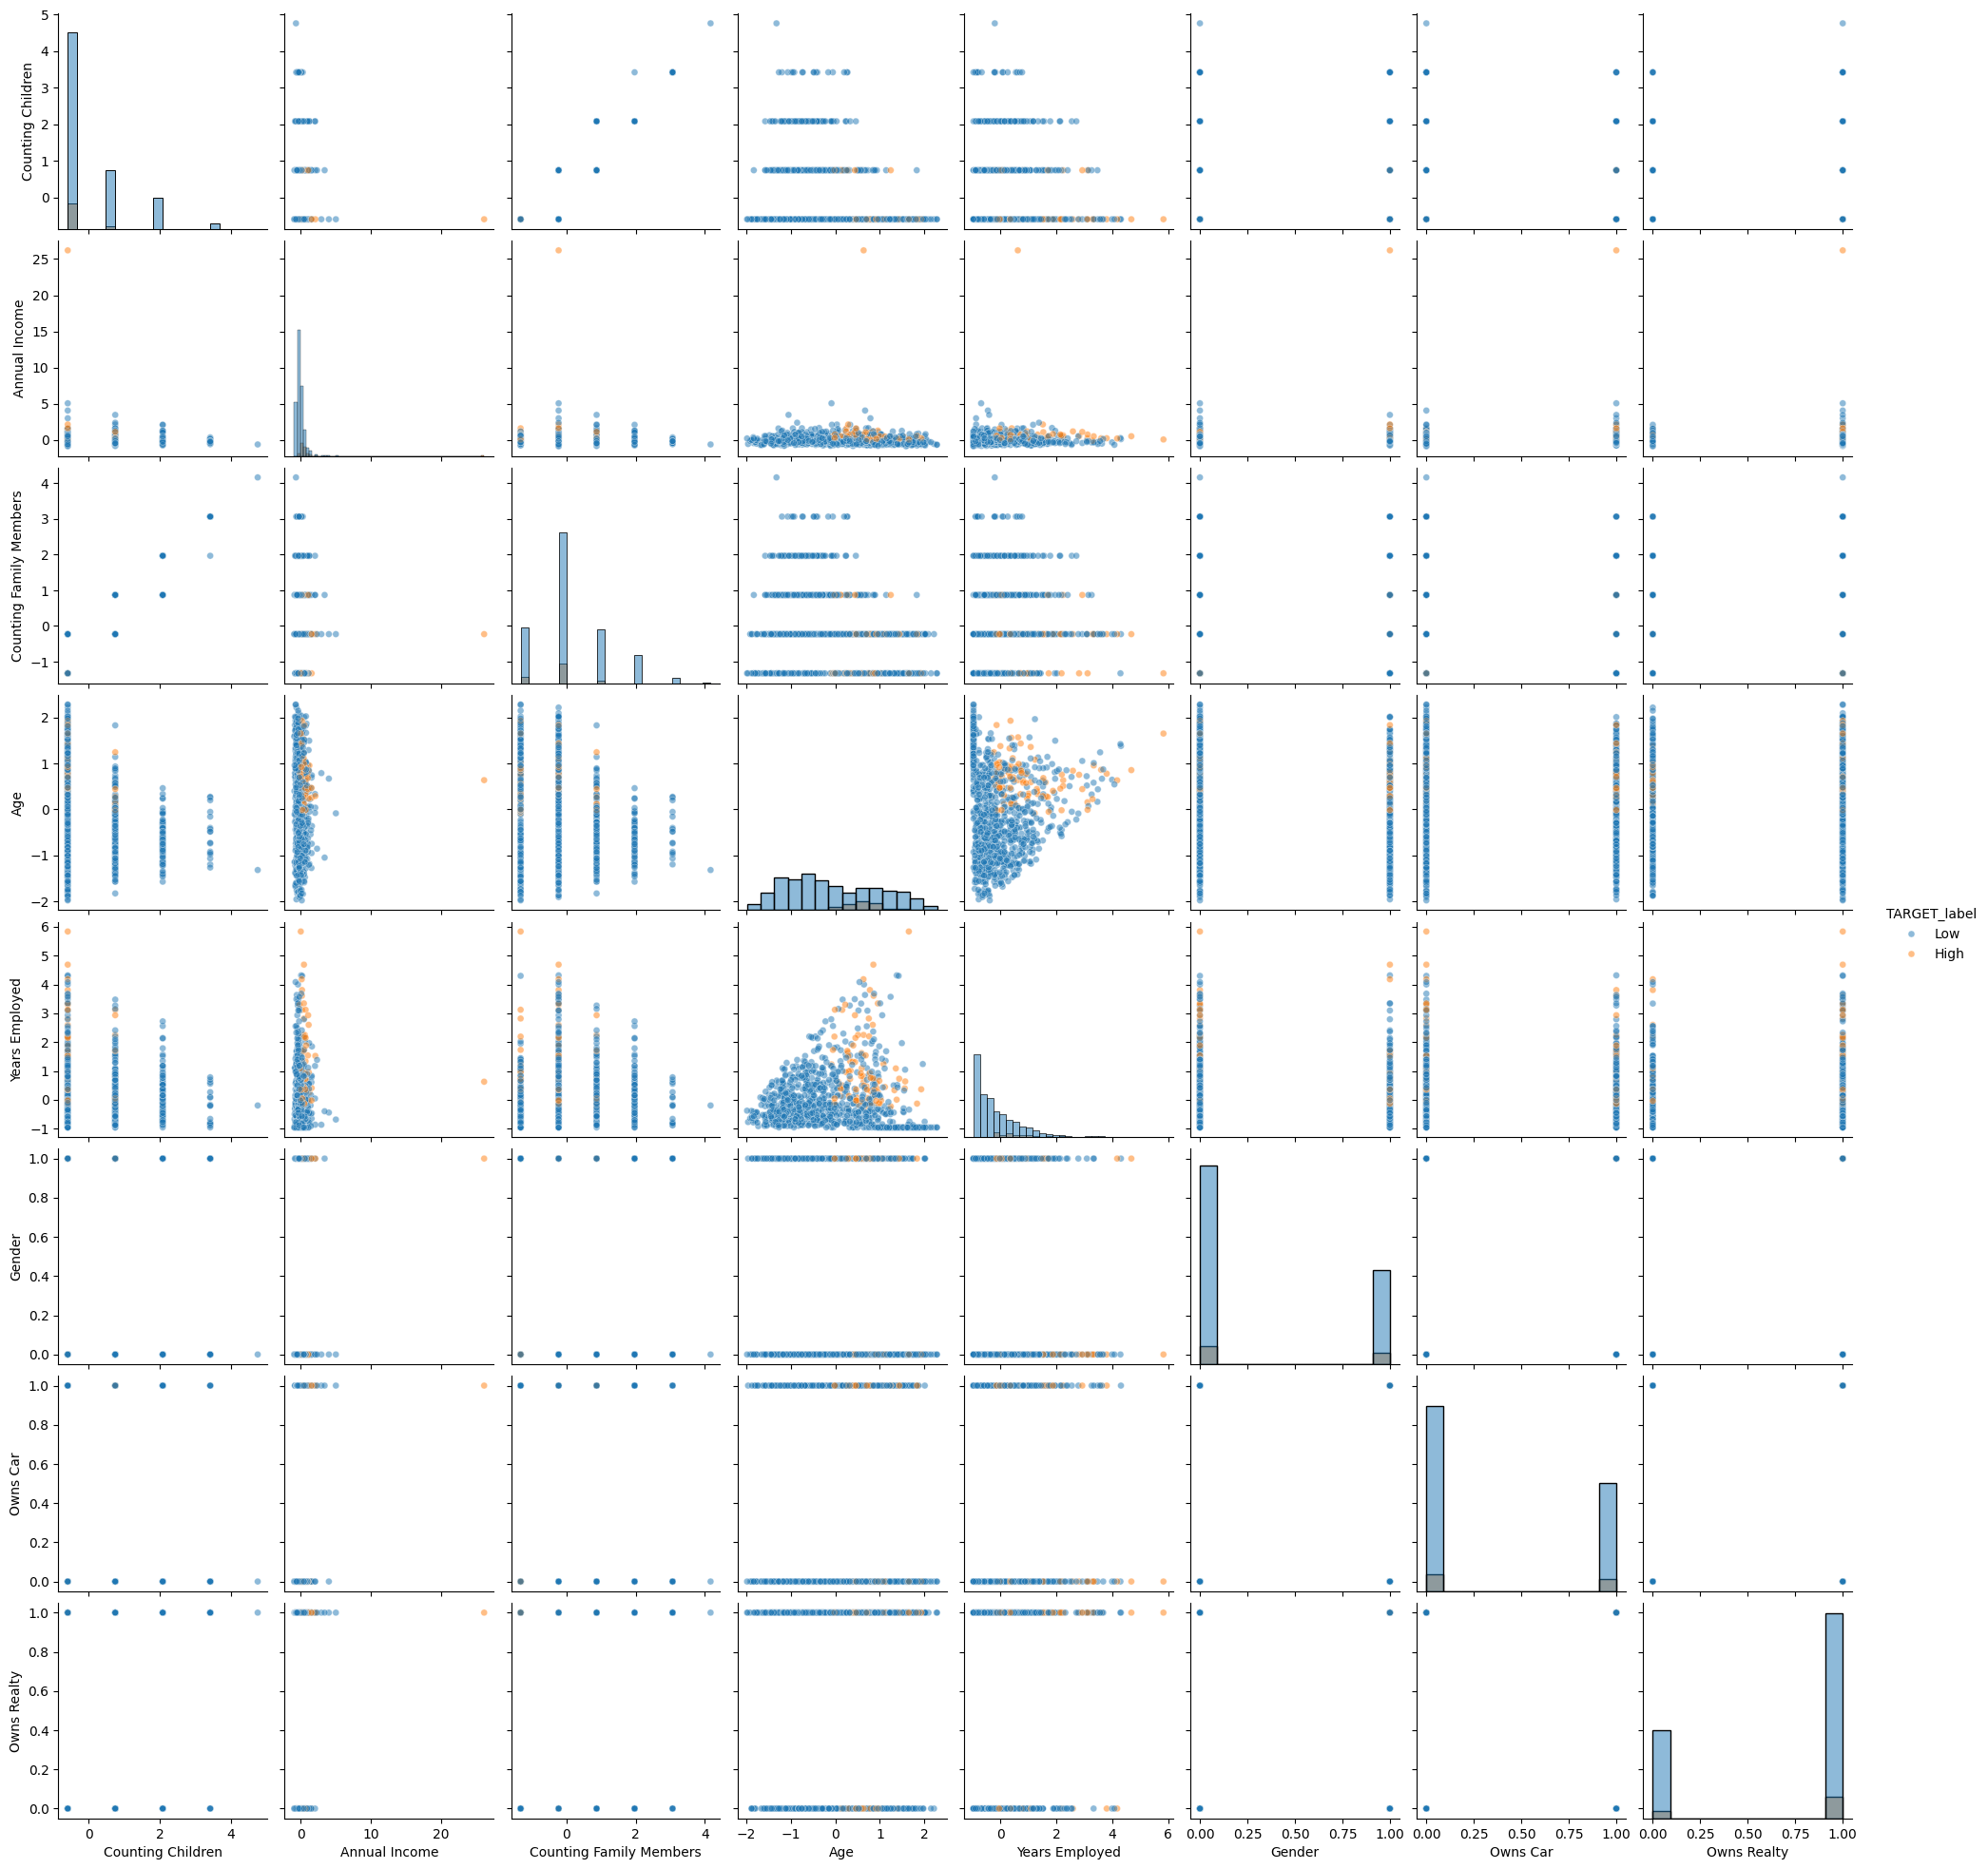

In [36]:
# Dizionario con nomi per le colonne
col_labels_plot = col_labels.copy()
col_labels_plot["YEARS_EMPLOYED"] = "Years Employed"

# Lista delle variabili da plottare (esclude il target)
pairplot_cols = continuous_variables + ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY"]

# Campione casuale per rendere il plot leggibile
df_sample = df_enc.sample(n=1000, random_state=RANDOM_SEED)

# Copia del dataframe per standardizzazione
df_sample_std = df_sample.copy()

# Standardizzazione solo delle variabili quantitative
scaler = StandardScaler()
df_sample_std[continuous_variables] = scaler.fit_transform(df_sample_std[continuous_variables])

# Colonna leggibile per il target
df_sample_std["TARGET_label"] = df_sample_std["TARGET"].map({0: "Low", 1: "High"})

# Rinomina delle colonne per visualizzazione
df_sample_std_renamed = df_sample_std.rename(columns=col_labels_plot)
pairplot_cols_renamed = [col_labels_plot.get(col, col) for col in pairplot_cols]

# Scatterplot matrix
sns.pairplot(
    df_sample_std_renamed,
    vars=pairplot_cols_renamed,   # solo variabili da plottare
    hue="TARGET_label",          # target come hue
    diag_kind="hist",
    plot_kws={"alpha": 0.5, "s": 25}
)

plt.show()

### Interpretazione della Scatterplot matrix

La scatterplot matrix suggerisce che, nel complesso, il dataset presenta bassa correlazione tra le variabili, ad eccezione di poche relazioni intuitive:

- tra *'numero di figli'* vs *'numero di membri della famiglia'* si osserva una chiara correlazione positiva: all’aumentare del numero di figli aumenta il numero di membri familiari, come atteso.
- tra *'età'* vs *'anni di occupazione'* si osserva una relazione positiva: individui più anziani tendono ad avere una maggiore anzianità lavorativa.


Per quanto riguarda le relazioni delle feature con il target, la scatterplot matrix suggerisce che nessuna coppia di variabili è in grado di separare chiaramente le classi poichè non si nota **nessuna separazione netta tra classi** e non ci sono cluster distinti. Questo significa che le variabili considerate **non permettono una separazione lineare o visiva chiara** tra clienti affidabili e non affidabili, e che l’affidabilità creditizia dipende da combinazioni non lineari di più variabili.

In una situazione come questa la Logistic Regression da sola potrebbe non essere in grado di rappressentare bene le relazioni tra i dati. Verranno quindi utilizzati anche modelli non lineari come Random Forest e Gradient Boosting per questo progetto.

### Verifica multicollinearità

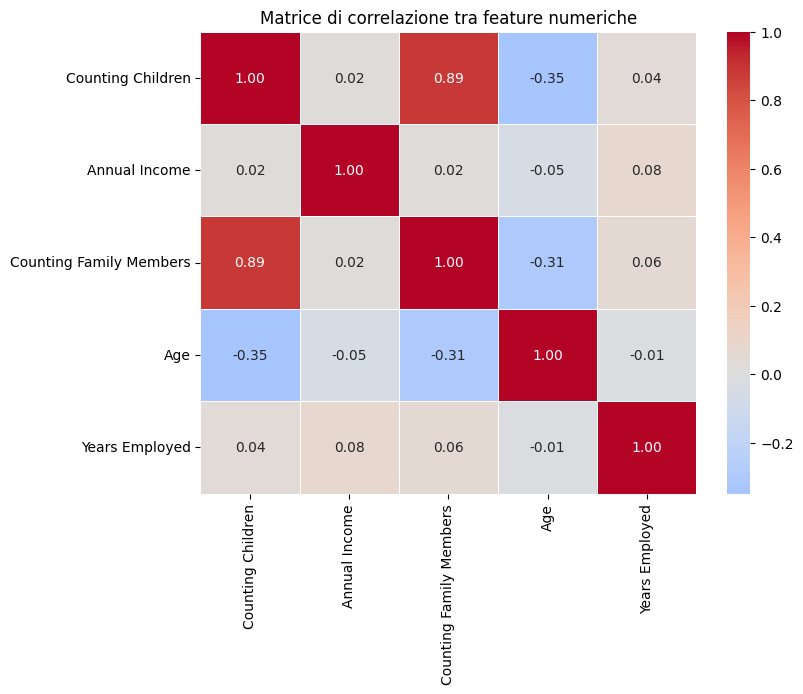

In [37]:
# feature numeriche
numeric_cols = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS", "AGE", "YEARS_EMPLOYED"]

# Rinomina delle colonne per visualizzazione
numeric_cols_renamed = [col_labels_plot.get(col, col) for col in numeric_cols]

# Rinomina del Dayaframe
df_corr = df_enc[numeric_cols].rename(columns=col_labels_plot)

# calcolo della matrice di correlazione
corr_matrix = df_corr.corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, 
            annot=True,      # mostra valori 
            fmt=".2f",       # 2 cifre decimali
            cmap="coolwarm", # colori
            center=0,        # centrato su 0
            linewidths=0.5
           )
plt.title("Matrice di correlazione tra feature numeriche")
plt.show()

### Interpretazione dei risultati

Dall'analisi della matrice di correlazione (in concordanza con l'analisi della scatterplot matrix) si nota una correlazione molto forte e positiva tra *' numero di figli'* e *'numero di membri della famiglia'*, infatti il numero di figli è naturalmente una componente del numero totale di membri della famiglia, quindi le due variabili contengono informazione in gran parte ridondante.

Queste feature potrebbero portare problemi di multicollinearità per modelli lineari come Logistic Regression, ma non sarebbero un problema per modelli ad albero come Decision Tree e Random Forest che gestiscono bene la ridondanza.

Una correlazione moderata, che non portano problemi di multicollinearità, è quella tra *'età'* e *'numero di figli'*: i clienti più giovani tendono ad avere più figli o famiglie più numerose, mentre clienti più anziani tendono ad avere meno figli a carico.

In conclusione, a eccezione della forte correlazione tra *' numero di figli'* e *'numero di membri della famiglia'*, le variabili numeriche mostrano correlazioni lineari deboli. Questo suggerisce che le relazioni tra le variabili e l’affidabilità creditizia potrebbero essere non lineari e dipendere da interazioni più complesse tra le feature.

# 3. Creazione e addestramento dei Modelli Predittivi

# A. Logistic Regression(modello baseline)

## A.1. Split dei dati in training set e test set

NOTA. Come suggerito dall'analisi della matrice di correlazione, per gestire la multicollinearità non verrà considerata la variabile *'numero di figli'*, ma solo *'numero di membri della famiglia'* per il modello di Logistic Regression. Si scelgie di tenere *'numero di membri della famiglia'* perchè è più informativa (include anche partner, non solo figli).

In [38]:
# Definizione delle feature
X = df_enc.drop(columns=["TARGET", "CNT_CHILDREN"]) 
# --> NOTA. Dal dataframe erano gà state rimosse le feature: "ID", "FLAG_MOBIL", "DAYS_EMPLOYED" e "DAYS_BIRTH"

# Definizione del target
y = df_enc["TARGET"]

# Crazione degli array di training e di test, usando il 30% dei dati per il test set:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,   # feature e target
    test_size=0.3,   # 30% dei dati per il test
    stratify=y,   # mantiene la stessa distribuzione di y in training set e test set
    random_state=RANDOM_SEED   # garantisce riproducibilità
)

## A.2. Preprocessamento dei dati e creazione del modello di Logistic Regression

Il preprocessamento dei dati che verrò eseguito comprende:

- **Standardizzazione --> variabili quantitative continue**
- **One-Hot Encoding --> variabili categoriche nominali**
- **Label encoding --> variabili categoriche binarie (sì/no)**. Questa trasformazione è stata già fatta manualmente per preparare i dati per la scatterplot matrix, e quindi non verrà ripetuta.


Vengono di seguito utilizzati il modulo **Pipeline di sklearn.pipeline** e la classe **ColumnTransformer di sklearn.compose** che consentono di rendere il flusso di lavoro automatico, con step ordinati, codice piulito ed evitare il data leakage o altri errori.

**Pipeline** è un modulo fondamentale nella libreria scikit-learn, utilizzato per incapsulare e automatizzare una sequenza di passaggi di Machine Learning all'interno di un unico oggetto:

- preprocessing dei dati (normalizzazione, codifica, gestione valori mancanti)
- creazione del modello di classificazione o regressione

NOTA. Utilizzare Pipeline evita il data leakage e garantisce l'ordine corretto degli step.


Il **Data leakage** si verifica quando informazioni provenienti da fuori dal set di addestramento (training set) vengono inavvertitamente incluse nel processo di modellazione. Questo porta ad avere metriche di performance eccezionalmente alte durante la validazione, ma a scarse capacità di generalizzazione e predittive su dati reali. 

Il data leakage si può verificare durante la fase di preprocessamento, se tutto il dataset viene utilizzato per calcolare informazioni che dovrebbero essere basate solo sul training set, quindi i dati del test set influenzano l'addestramento. Per questo motivo trasformazioni come la standardizzazione e il One-hot encoding devono essere fatte solo sul training test.

Label encoding e Ordinal encoding, invece, possono essere fatti prima dello split dei dati in trainig set e test set (quindi vengono applicati a tutti i dati) perchè: sono dei semplici mapping deterministici, non dipendono dal target, non imparano nulla dai dati e non si usano per calcolare statistiche.


**ColumnTransformer** è una classe di sklearn.compose (libreria scikit-learn) utilizzata per applicare trasformazioni differenti a specifiche colonne di un dataset, e poi concatenare tutto in un’unica matrice. ColumnTransformer è ottima per la gestione di dataset con dati misti: ad esempio colonne numeriche a cui applicare 'StandardScaler' e colonne categoriche a cui applicare 'OneHotEncoder'.

**NOTA - Gestione dello sbilanciamento delle classi della variabile *'TARGET'***. La gestione dello sbilanciamento è essenziale perchè quando una classe è molto più frequente dell'altra (come accade in questo studio) il modello tende a ignorare la classe minoritaria, facendo sempre previsioni che coincidono con la classe maggioritaria, ottenendo alta precisione generale ma pessimi risultati nel riconoscere esempi della classe minoritaria. 

Per gestire lo sbilanciamento delle classi della variabile *'TARGET'* si utilizza il parametro **class_weight="balanced"** che penalizza la classe più frequente nel modello: l'algoritmo regola i pesi in modo inversamente proporzionale alle frequenze delle classi nei dati di input, cioè assegna un peso maggiore alla classe minoritaria e un peso minore a quella maggioritaria.

Questo implica che durante l'addestramento, gli errori che il modello commette su un esempio di classe minoritaria avranno un peso maggiore, quindi verranno disincentivati maggiormente rispetto agli errori sugli esempio della classe maggioritaria.

In [39]:
df_enc.info()

<class 'pandas.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CODE_GENDER          338426 non-null  int64  
 1   FLAG_OWN_CAR         338426 non-null  int64  
 2   FLAG_OWN_REALTY      338426 non-null  int64  
 3   CNT_CHILDREN         338426 non-null  int64  
 4   AMT_INCOME_TOTAL     338426 non-null  float64
 5   NAME_INCOME_TYPE     338426 non-null  str    
 6   NAME_EDUCATION_TYPE  338426 non-null  str    
 7   NAME_FAMILY_STATUS   338426 non-null  str    
 8   NAME_HOUSING_TYPE    338426 non-null  str    
 9   FLAG_WORK_PHONE      338426 non-null  int64  
 10  FLAG_PHONE           338426 non-null  int64  
 11  FLAG_EMAIL           338426 non-null  int64  
 12  OCCUPATION_TYPE      338426 non-null  str    
 13  CNT_FAM_MEMBERS      338426 non-null  int64  
 14  TARGET               338426 non-null  int64  
 15  AGE                  338426 

In [40]:
# Raggruppamento delle variabili per il prepocessamento:

# variabili numeriche a cui applicare la syandardizzazione:
# NOTA. "CNT_CHILDREN" non viene considerata perchè insieme a "CNT_FAM_MEMBERS" porta a multicollinearità
numeric_features = ["AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS", "AGE", "YEARS_EMPLOYED"]

# Variabili categoriali a cui applicare one-hot encoding
categorical_features = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", 
                        "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]

# Variabili binarie i cui valori sono interi 0/1: è già stato applicato Label Encoding
# Anche "TARGET" è già in formato 0/1
binary_features = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
                   "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"]

In [41]:
# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),   # applica .fit_transform() di StandardScaler al training-set
                                                   # e applica .transform() di StandardScaler al test-set
                                                   # in questo modo l'addestramento viene fatto solo sul training-set, evitando il data leakage
    ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),  # One-hot encoding solo sul train test
    ("bin", "passthrough", binary_features)
])

# Modello di Logistic Regression
balanced_lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced", # penalizza maggiormente gli errori sulla classe minoritaria   
        max_iter=1000,  # numero di iterazioni massime dell’algoritmo di ottimizzazione
        random_state=RANDOM_SEED))  # riproducibilità dei risultati
])

## A.3. Stratified K-Fold Cross-Validation e valutazione dei modelli

Per la Stratified K-Fold Cross-Validation si divide il dataset in k sottoinsiemi (fold) di dimensioni simili, mantenendo la stessa distribuzione della variabile target in ogni fold. Questo aspetto è importante per problemi di classificazione con classi sbilanciate come questo.

Ad ogni iterazione, uno dei fold viene usato come test set e gli altri k-1 come training set. Si ripete k volte, così ogni fold viene usato una volta come test. Alla fine si calcola la media delle metriche di performance

In [42]:
# Configurazione del cross-validator:
cv = StratifiedKFold(n_splits=5, # divide i dati in 5 fold mantenendo la proporzione delle classi in ciascun fold
                     shuffle=True, # mescola i dati prima di dividerli, riducendo la possibilità di avere fold sbilanciati
                     random_state=RANDOM_SEED) # garantisce riproducibilità

# Funzione per Cross-validation

def evaluate_model_cv(model, X, y, cv, scoring_metrics=None, model_name="Model"):
    """
    Esegue la cross-validation e restituisce un dataframe riassuntivo delle metriche.

    Args:
    - model: modello sklearn
    - X: feature
    - y: target
    - cv: oggetto cross-validator (es. StratifiedKFold)
    - scoring_metrics: lista metriche (default: AUC, Precision, Recall, F1-score, Accuracy)
    - model_name: nome del modello (per output)

    Returns:
    - df_summary: dataframe con mean e std delle metriche
    """

    # Definizione delle metriche
    if scoring_metrics is None:
        scoring_metrics = ["roc_auc", "precision", "recall", "f1", "accuracy"]

    # cross-validation
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring_metrics)

    # titolo
    display(Markdown(f"### **{model_name}**"))

    # costruzione dataframe
    df_summary = pd.DataFrame({
        "Metric": ["AUC", "Precision", "Recall", "F1", "Accuracy"],
        "Mean": [
            scores['test_roc_auc'].mean().round(3),
            scores['test_precision'].mean().round(3),
            scores['test_recall'].mean().round(3),
            scores['test_f1'].mean().round(3),
            scores['test_accuracy'].mean().round(3)
        ],
        "Std": [
            scores['test_roc_auc'].std().round(3),
            scores['test_precision'].std().round(3),
            scores['test_recall'].std().round(3),
            scores['test_f1'].std().round(3),
            scores['test_accuracy'].std().round(3)
        ]
    })

    return df_summary

In [43]:
df_results_balanced = evaluate_model_cv(
    balanced_lr_model,
    X_train,
    y_train,
    cv,
    model_name="Balanced Logistic Regression"
)

display(df_results_balanced)

### **Balanced Logistic Regression**

,Metric,Mean,Std
0,AUC,0.918,0.001
1,Precision,0.319,0.002
2,Recall,0.882,0.003
3,F1,0.469,0.002
4,Accuracy,0.824,0.002


### Interpretazione dei risultati

- **AUC è molto alta** (0.918) e indica quindi che il modello di Logistic Regression distingue molto bene tra clienti affidabili e non.
- **Precision è bassa** (0.319) e indica che solo il 31.9% dei clienti classificati come affidabili del modello, sono davvero affidabili. Questo significa che ci **sono molti falsi positivi**: potrebbe essere un problema perchè la banca tenderebbe e concedere credito a clienti non affidabili.
- **Recall è molto alto** (0.882) e indica che il modello identifica correttamente circa l’88% dei clienti affidabili. Questo significa che ci sono **pochi falsi negativi**.
- **Fi-score è discreto** (0.469) poichè, essendo influenzato sia da Precision che da Recall, viene abbassato da Precision.
- Accuracy sembra alta, ma non è affidabile per dataset sbilanciati come questo, quindi non viene considerata come metrica principale.

Il modello di Logistic Regression a questo punto risulta troppo rischioso, dal momento che concede credito a clienti non affidabili. 

**Per ridurre i falsi positivi si utilizzeranno le seguenti strategie**:

- 1. non utilizzare il parametro *class_weight="balanced"*, che rende la classe minoritaria più importante, privilegiando la riduzione dei falsi negativi a scapito dei falsi positivi.
- 2. trovare la soglia (threshold) ottimale, alzandola rispetto al default di 0.5

In [44]:
# Modello di Logistic Regression NON bilanciato
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,  # numero di iterazioni massime dell’algoritmo di ottimizzazione
        random_state=RANDOM_SEED))  # riproducibilità dei risultati
])


# Applicazione della funzione per Cross-validation
df_results_balanced = evaluate_model_cv(
    lr_model,
    X_train,
    y_train,
    cv,
    model_name="Logistic Regression"
)

display(df_results_balanced)

### **Logistic Regression**

,Metric,Mean,Std
0,AUC,0.916,0.001
1,Precision,0.514,0.006
2,Recall,0.203,0.004
3,F1,0.291,0.004
4,Accuracy,0.913,0.000


### Interpretazione dei risultati

Il modello non bilaciato presenta:
- **AUC molto alta** (0.916), con una differenza non significativa rispetto al modello bilanciat (0.918). Questo indica che entrambi i modelli distinguono molto bene tra clienti affidabili e non.
- **Precision è aumentata** da 0.319 del modello bilanciato a 0.514. Questo significa che il modello non bilanciato mostra **meno falsi positivi**: il 51.5% dei clienti classificati come affidabili del modello, sono davvero affidabili.
- **Recall è molto basso** (0.203) rispetto al modello bilaciato (0.883) e indica che il modello identifica correttamente solo il 20% dei clienti affidabili. Questo significa che ci sono **molti falsi negativi**.
- **Fi-score è basso** (0.291), diminuito rispetto al modello bilanciato (0.469). 
- Accuracy sembra alta, ma non è affidabile per dataset sbilanciati come questo, quindi non viene considerata come metrica principale.

**Confronto tra i modelli:**

I due modelli presentano AUC simili, quindi hanno capacità predittiva comparabile.

Dal momento che F1 misura equilibrio tra precision e recall, il modello bilanciato appare globalmente migliore.

Tuttavia per una banca è molto importante ridurre il rischio di concedere credito a clienti non affidabili. Quindi da questo punto di vista il modello migliore sembra essere quello non bilanciato. Infatti il modello non bilanciato è molto più prudente nel concedere credito (Precision più alta), nonostante abbia il difetto di rifiutare molti clienti affidabili (Recall più basso).

Si sceglie quindi di continuare l'analisi del modello non bilanciato, che è più coerente con l'obiettivo di massimizzare la precision per minimizzare i falsi positivi. 

## A.4. Threshold ottimale

L'obiettivo è trovare il threshold ottimale tale che:
- Precision ≥ target (es. 0.6)
- e tra questi scegliere quello con Recall massimo

Il training set è stato ulteriormente suddiviso in training e validation set per evitare data leakage nella selezione del threshold decisionale.

In [45]:
# Suddivisione del datset in training set e validation set

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_SEED
)

In [46]:
# addesramento del modello
lr_model.fit(X_train_sub, y_train_sub)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [47]:
# Predizioni
y_prob_val = lr_model.predict_proba(X_val)[:, 1]

In [48]:
# Funzione per trovare il threshold ottimale

def find_threshold_with_precision_constraint(y_true, y_prob, min_precision=0.6, plot_roc=True):
    """
    Trova il threshold ottimale tale che precision >= min_precision e massimizza il recall.
    Mostra anche la ROC curve se plot_roc=True.

    Args:
        y_true: array-like, valori reali (0/1)
        y_prob: array-like, probabilità predette
        min_precision: float, vincolo minimo sulla precision
        plot_roc: bool, se True mostra la curva ROC

    Returns:
        best_threshold: threshold ottimale
        df_results: dataframe con tutti i risultati
    """
    
    thresholds = np.linspace(0, 1, 500)
    
    results = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred)
        
        results.append([t, precision, recall])

    df_results = pd.DataFrame(results, columns=["threshold", "precision", "recall"])

    # Filtra soglie che rispettano il vincolo
    df_valid = df_results[df_results["precision"] >= min_precision]

    if len(df_valid) == 0:
        print("Nessuna soglia soddisfa il vincolo di precision.")
        best_threshold = None

    # SOLO SE ESISTE UN THRESHOLD OTTIMALE PER IL VALORE DI PRECISION MINIMO IMPOSTATO:
    
    else:
        # Scegli quella con recall massimo
        best_row = df_valid.loc[df_valid["recall"].idxmax()]
        best_threshold = best_row["threshold"]
        print(f"Threshold ottimale: {best_threshold:.4f}")
        print(f"Precision: {best_row['precision']:.4f}")
        print(f"Recall: {best_row['recall']:.4f}")

        
        if plot_roc:
            fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(8,6))
            plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
            plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
            
            # evidenzia il punto corrispondente alla soglia ottimale (se definita)
            if best_threshold is not None:
                # Trova l'indice nella lista di soglie della ROC più vicina al threshold ottimale
                idx_opt = np.argmin(np.abs(roc_thresholds - best_threshold))
                
                plt.scatter(fpr[idx_opt], tpr[idx_opt],
                            color='red',
                            label=f'Optimal threshold = {best_threshold:.2f}')


            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate (Recall)')
            plt.title('ROC Curve')
            plt.legend(loc='lower right')
            plt.grid()
            plt.show()

    return best_threshold, df_results

In [49]:
# applico la funzione per trovare il threshold ottimale
threshold_opt, df_thresh = find_threshold_with_precision_constraint(
    y_val,
    y_prob_val,
    min_precision=0.6
)

Nessuna soglia soddisfa il vincolo di precision.


In [50]:
# massima precision ottenibile:
df_thresh["precision"].max()

np.float64(0.5772357723577236)

Threshold ottimale: 0.8978
Precision: 0.5772
Recall: 0.0171


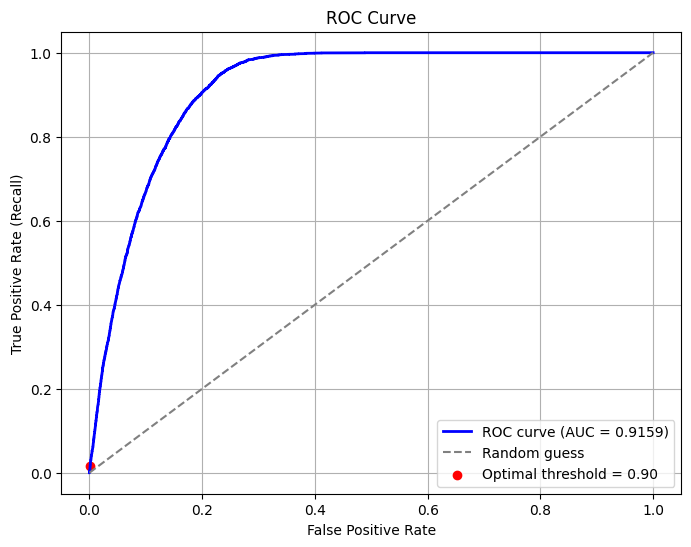

In [51]:
threshold_opt, df_thresh = find_threshold_with_precision_constraint(
    y_val,
    y_prob_val,
    min_precision=0.577
)

### NOTA - Threshold ottimale

Il posizionamento del punto di soglia ottimale nell'angolo in basso a sinistra della curva ROC (caratterizzato da bassi valori di False Positive Rate e True Positive Rate) riflette l'imposizione di un vincolo di Precision particolarmente stringente (precision massima cioè 0.577). Questa **elevata selettività** del modello comporta una riduzione dei "Falsi Positivi", ma al costo di un elevato numero di "Falsi Negativi", **abbassando drasticamente il Recall** e posizionando il punto del Threshold ottimale sulla curva vicino all'origine degli assi. 

Al contrario, riducendo il requisito di precisione minima, si osserva uno spostamento del punto verso la concavità della curva, quindi il recall migliora e si riescono a intercettare molti più clienti affidabili. Tuttavia la precision diminuisce drasticamente, e questo non è indicato se il fine del progetto è è minimizzare il rischio di concedere credito a clienti non affidabili, ovvero ridurre i falsi positivi della classe 1 (clienti classificati come affidabili ma in realtà rischiosi). Di seguito viene mostrata la ROC-AUC per un valore meno stringente di Precision:

Threshold ottimale: 0.0902
Precision: 0.3021
Recall: 0.9089


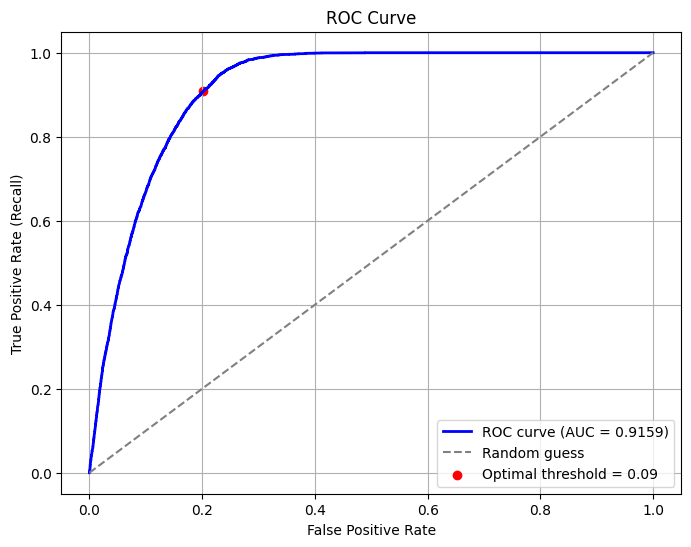

In [52]:
threshold_opt_b, df_thresh_b = find_threshold_with_precision_constraint(
    y_val,
    y_prob_val,
    min_precision=0.3
)

## A.8. Valutazione del modello con threshold ottimale

In [53]:
# Calcolo delle predizioni sul test set con threshold ottimale
y_prob_test = lr_model.predict_proba(X_test)[:, 1]
y_pred_test_opt = (y_prob_test >= threshold_opt).astype(int)

Metriche modello con threshold ottimale:


,Metric,Value
0,Precision,0.606061
1,Recall,0.020186
2,F1-score,0.039071
3,Accuracy,0.912793


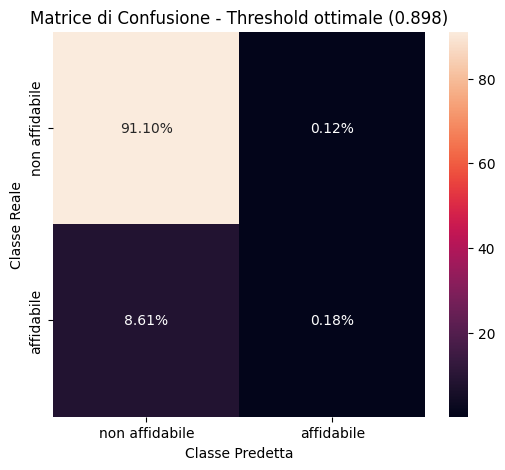

In [54]:
# Metriche principali
precision = precision_score(y_test, y_pred_test_opt)
recall = recall_score(y_test, y_pred_test_opt)
f1 = f1_score(y_test, y_pred_test_opt)
accuracy = accuracy_score(y_test, y_pred_test_opt)

df_metrics = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score", "Accuracy"],
    "Value": [precision, recall, f1, accuracy]
})

print("Metriche modello con threshold ottimale:")
display(df_metrics)


# Matrice di confusione
labels = ["non affidabile", "affidabile"]

cm = confusion_matrix(y_test, y_pred_test_opt)
cm_percent = cm / cm.sum() * 100  # percentuale sul totale

# Heatmap percentuale
annot = np.array([["{:.2f}%".format(v) for v in row] for row in cm_percent])
df_cm_percent = pd.DataFrame(cm_percent, index=labels, columns=labels)

plt.figure(figsize=(6,5))
sns.heatmap(df_cm_percent, annot=annot, fmt="")
plt.ylabel("Classe Reale")
plt.xlabel("Classe Predetta")
plt.title(f"Matrice di Confusione - Threshold ottimale ({threshold_opt:.3f})")
plt.show()

**Interpretazione dei risultati**

Il modello di Logistic Regression mostra una buona capacità discriminante (con AUC alta: ≈ 0.91), ma presenta **limiti significativi in termini di precisione e recall**. In particolare, non è possibile individuare una soglia decisionale che garantisca una precisione superiore al 60%, indicando una limitata separabilità tra le classi.

Inoltre, l’ottimizzazione del threshold porta a un modello estremamente conservativo, con un recall molto basso (≈ 0.02), rendendolo poco utilizzabile in un contesto reale.

Questi risultati suggeriscono che la Logistic Regression, essendo un modello lineare, **non è in grado di catturare le relazioni complesse tra le variabili**. È quindi opportuno utilizzare modelli non lineari, come Random Forest o Gradient Boosting, per migliorare le performance.

-----------------------------------------------------------

# B. Decision Tree

Il modello Decision Tree Classifier è stato scelto per prevedere l’affidabilità creditizia perché:
- è in grado di catturare **relazioni non lineari tra le feature** (che rimane un limite per la Locgistic Regression)
- possiede un’**elevata interpretabilità**, permettendo di tracciare il percorso decisionale che porta a classificare un cliente come affidabile o meno, e quindi permettendo di fornire al cliente le motivazioni in caso di rifiuto della concessione della carta di credito

## B.1. Preprocessamento

Si utilizza il dataframe df che ha già subito:

- **Gestione dei dati mancanti**: rimozione dei NaN per le features con 1 NaN (non ha alcun impatto statistico), e ssotituzione dei NaN con "Unknown" per la variabile *'tipo di occupazione'* che presenta molti NaN.
- Gestione di valori infiniti: non ci sono valori infiniti.
- Gestione di duplicati: non ci sono duplicati.
- **conversione delle variabili 0/1** da float a interi
- **Rimozione delle variabili** 'ID' e "FLAG_MOBIL"
- **Gestione dei valori anomali** molto alti di 'DAYS_EMPLOYED', che sono valori placeholder/anomali usati per indicare clienti non occupati o pensionati. Analizzando il dataset si è osservato che tuttu i valori anomali corrispondono a pensionati, e sono stati sostituiti con zero-
- **Gestione dei valori negativi e molto alti** di 'DAYS_EMPLOYED' e 'DAYS_BIRTH': le feature vengono trasformate in anni e rappresentano 'età' e 'anni di occupazione'.

Dato che un modello Decision Tree in sklearn non accetta stringhe, si continua il preprocessamento con:

- **One-Hot Encoding** delle variabili categoriche

NOTA. NON è necessario eseguire Standardizzazione o Normalizzazione delle feature continue perchè gli alberi non usano le distanze, quindi ignorano la scala

In [55]:
df_enc.info()

<class 'pandas.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CODE_GENDER          338426 non-null  int64  
 1   FLAG_OWN_CAR         338426 non-null  int64  
 2   FLAG_OWN_REALTY      338426 non-null  int64  
 3   CNT_CHILDREN         338426 non-null  int64  
 4   AMT_INCOME_TOTAL     338426 non-null  float64
 5   NAME_INCOME_TYPE     338426 non-null  str    
 6   NAME_EDUCATION_TYPE  338426 non-null  str    
 7   NAME_FAMILY_STATUS   338426 non-null  str    
 8   NAME_HOUSING_TYPE    338426 non-null  str    
 9   FLAG_WORK_PHONE      338426 non-null  int64  
 10  FLAG_PHONE           338426 non-null  int64  
 11  FLAG_EMAIL           338426 non-null  int64  
 12  OCCUPATION_TYPE      338426 non-null  str    
 13  CNT_FAM_MEMBERS      338426 non-null  int64  
 14  TARGET               338426 non-null  int64  
 15  AGE                  338426 

In [56]:
df_dec_tree = df_enc.copy()

In [57]:
# Raggruppamento delle variabili per il preprocessamento
cat_cols = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]
bin_cols = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY"]
num_cols = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "CNT_FAM_MEMBERS", "AGE", "YEARS_EMPLOYED"]

In [58]:
df_dec_tree.info()

<class 'pandas.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CODE_GENDER          338426 non-null  int64  
 1   FLAG_OWN_CAR         338426 non-null  int64  
 2   FLAG_OWN_REALTY      338426 non-null  int64  
 3   CNT_CHILDREN         338426 non-null  int64  
 4   AMT_INCOME_TOTAL     338426 non-null  float64
 5   NAME_INCOME_TYPE     338426 non-null  str    
 6   NAME_EDUCATION_TYPE  338426 non-null  str    
 7   NAME_FAMILY_STATUS   338426 non-null  str    
 8   NAME_HOUSING_TYPE    338426 non-null  str    
 9   FLAG_WORK_PHONE      338426 non-null  int64  
 10  FLAG_PHONE           338426 non-null  int64  
 11  FLAG_EMAIL           338426 non-null  int64  
 12  OCCUPATION_TYPE      338426 non-null  str    
 13  CNT_FAM_MEMBERS      338426 non-null  int64  
 14  TARGET               338426 non-null  int64  
 15  AGE                  338426 

## B.2. Creazione e addestramento del modello

Come per il modello di Logistic Regression, vengono di seguito utilizzati il **modulo Pipeline di sklearn.pipeline** e la **classe ColumnTransformer di sklearn.compose** che consentono di rendere il flusso di lavoro automatico, con step ordinati, codice piulito ed evitare il data leakage o altri errori.

Vengono confrontati due modelli Decision Tree: uno con il parametro *class_weight="balanced"* che è usato per un dataset sbilanciato per penalizzare maggiormente gli errori sulla classe minoritaria, e un modello senza il parametro.

In [59]:
# Preprocessing
preprocessor_df = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ("bin", "passthrough", bin_cols),
    ("num", "passthrough", num_cols)
])

In [60]:
# Funzione per la creazione dei modelli

def create_model(preprocessor, class_weight):
    """
    Crea un modello di Decision Tree integrato in una Pipeline con preprocessamento.

    Parametri:
    - preprocessor: oggetto di tipo ColumnTransformer che gestisce il preprocessing delle feature
                    (ad esempio One-Hot Encoding per le variabili categoriche e passthrough per le numeriche)
    - class_weight: parametro per bilanciare le classi nella DecisionTreeClassifier.
                    Può essere 'balanced' o None, a seconda della strategia scelta per gestire lo sbilanciamento

    Output:
    - Restituisce un oggetto Pipeline pronto per essere addestrato su training set,
      con due step principali:
        1. preprocessing: applica il preprocessing definito al dataset
        2. model: DecisionTreeClassifier con profondità massima limitata (max_depth=5) 
                  e classe random_state=0 per garantire riproducibilità

    Note:
    - La funzione facilita la creazione di modelli coerenti e riutilizzabili in esperimenti comparativi.
    - Può essere utilizzata sia per modelli bilanciati che non bilanciati, semplicemente cambiando class_weight.
    """
    return Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(
            class_weight=class_weight,
            max_depth=5,
            random_state=RANDOM_SEED
        ))
    ])


# Creazione del Modello bilanciato
tree_bal = create_model(preprocessor_df, class_weight="balanced")

# Creazione del Modello NON bilanciato
tree_unbal = create_model(preprocessor_df, class_weight=None)

In [61]:
# Split
X_dt = df_dec_tree.drop("TARGET", axis=1)
y_dt = df_dec_tree["TARGET"]

X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(
    X_dt, y_dt,
    test_size=0.2,
    stratify=y_dt,
    random_state=RANDOM_SEED
)

In [62]:
# Funzione per addestramento sul traing set completo e valutazione del modello

def train_and_evaluate(model, X_train, X_test, y_train, y_test, name="Model"):
    """
    Addestra un modello di classificazione e ne valuta le prestazioni sul set di test.
    Consente di confrontare facilmente più modelli, mantenendo una procedura
    standardizzata di training e valutazione.
    
    Parametri:
    - model: modello di machine learning (es. Pipeline sklearn) da addestrare
    - X_train: feature del training set
    - X_test: feature del test set
    - y_train: target del training set
    - y_test: target del test set
    - name (str): nome del modello, utilizzato per identificare l’output a video

    Output:
    - Stampa il classification report (precision, recall, f1-score) per ciascuna classe
    - Mostra la confusion matrix grafica (con percentuali e valori assoluti) per analizzare nel dettaglio le predizioni
    - Restituisce il modello addestrato
    """

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    
    labels = ["non affidabile", "affidabile"]
    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm / cm.sum() * 100  # percentuale sul totale

    # Annotazioni combinate (valore assoluto + percentuale)
    annot = np.empty_like(cm).astype(str)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.2f}%)"

    df_cm = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(6,5))
    sns.heatmap(df_cm_percent, annot=annot, fmt="")
    plt.ylabel("Classe Reale")
    plt.xlabel("Classe Predetta")
    plt.title(f"Matrice di Confusione - {name}")
    plt.show()

    
    # ROC CURVE
    # Probabilità della classe positiva
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")  # linea random
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend(loc="lower right")
    plt.show()

    return model


===== Decision Tree (balanced) =====

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     61742
           1       0.63      0.99      0.77      5944

    accuracy                           0.95     67686
   macro avg       0.81      0.97      0.87     67686
weighted avg       0.97      0.95      0.95     67686



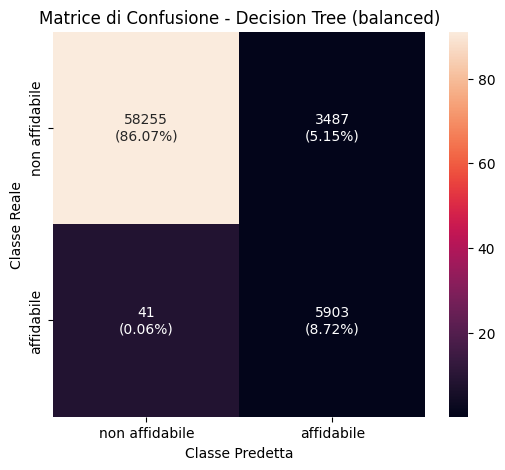

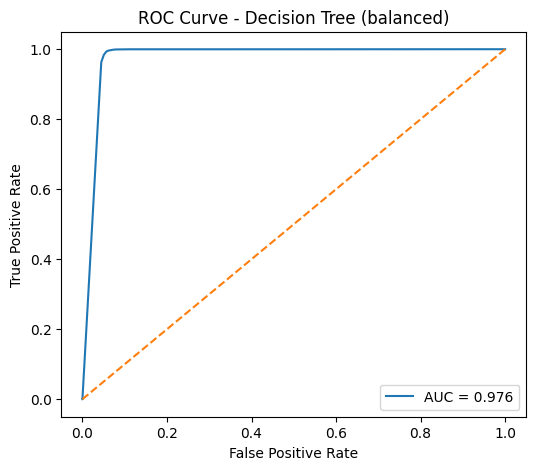


===== Decision Tree (unbalanced) =====

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     61742
           1       0.69      0.93      0.79      5944

    accuracy                           0.96     67686
   macro avg       0.84      0.94      0.88     67686
weighted avg       0.97      0.96      0.96     67686



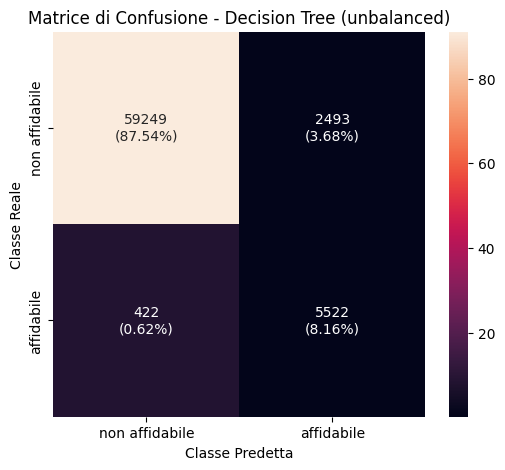

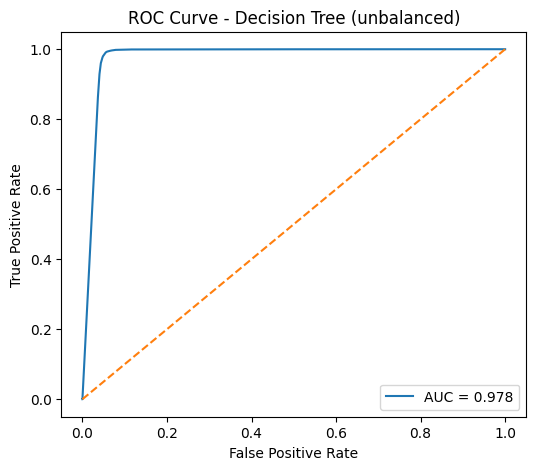

In [63]:
# Addestramento e valutazione dei modelli
model_bal = train_and_evaluate(
    tree_bal, X_dt_train, X_dt_test, y_dt_train, y_dt_test, 
    name="Decision Tree (balanced)"
)

model_unbal = train_and_evaluate(
    tree_unbal, X_dt_train, X_dt_test, y_dt_train, y_dt_test, 
    name="Decision Tree (unbalanced)"
)

### Interpretazione dei risultati

L’obiettivo principale dell’analisi è minimizzare il rischio di concedere credito a clienti non affidabili, ovvero ridurre i falsi positivi della classe 1 (clienti classificati come affidabili ma in realtà rischiosi).

Il modello con *class_weight="balanced"* mostra un recall molto elevato per la classe 1 (0.99), indicando una capacità quasi perfetta di identificare i clienti affidabili. Tuttavia, questo avviene a discapito della precision (0.63)): il modello tende infatti a classificare come affidabili anche molti clienti rischiosi. Questo si traduce in un numero elevato di falsi positivi (3487 casi, che corrisponde al 5.15% rispetto al totale delle previsioni), rendendo il modello **più permissivo** e aumentando il rischio creditizio.

Il modello senza bilanciamento (*class_weight=None*) presenta una precisione più elevata per la classe 1 (0.69) e una riduzione significativa dei falsi positivi (2493 casi, che corrisponde al 3.68% rispetto al totale delle previsioni). Sebbene il recall diminuisca leggermente (0.93), comportando l’esclusione di una quota maggiore di clienti affidabili (falsi negativi), il modello risulta **più conservativo e coerente con l’obiettivo di ridurre il rischio**.

L'Accuracy risulta elevata in entrambi i casi, ma non è considerata una metrica affidabile in presenza di dataset sbilanciati, poiché può fornire una valutazione fuorviante delle prestazioni del modello.

Per quanto riguarda la ROC-AUC, entrambi i modelli mostrano prestazioni eccellenti:
- modello bilanciato: AUC = 0.976
- modello non bilanciato: AUC = 0.978

La differenza è minima, indicando che i due modelli hanno una capacità molto simile di discriminare tra le classi.

In conclusione, considerando il contesto applicativo, il modello senza bilanciamento delle classi risulta preferibile, in quanto riduce il numero di clienti rischiosi erroneamente classificati come affidabili, garantendo una maggiore sicurezza nelle decisioni di concessione del credito, a fronte di una moderata perdita di clienti affidabili.

Si procede quindi all'ottimizzazione del modello selezionato (non bilanciato), con l’obiettivo di migliorare ulteriormente la precision della classe 1 senza compromettere eccessivamente il recall.

# B.3. Tuning e Pruning

**Tuning**

Con *Tuning* si intende la scelta dei migliori iperparametri del modello al fine di ottimizzarne le prestazioni.

Nel presente caso, l’obiettivo è migliorare la precision della classe 1 (clienti affidabili) senza ridurre eccessivamente il recall, mantenendo quindi un buon equilibrio tra riduzione dei falsi positivi e capacità di identificare correttamente i clienti affidabili.

Gli iperparametri considerati sono:

- *max_depth* : rappresenta la profondità massima dell’albero. Aumentare la profondità consente al modello di catturare relazioni più complesse nei dati, ma può portare a overfitting se non controllato.
- *min_samples_leaf* : indica il numero minimo di osservazioni richieste in una foglia. Valori più elevati rendono il modello più stabile e meno sensibile al rumore, contribuendo a ridurre l’overfitting e, in alcuni casi, anche i falsi positivi.
- *min_samples_split* : definisce il numero minimo di campioni necessario per effettuare uno split di un nodo. Valori più alti limitano la crescita dell’albero, evitando suddivisioni basate su poche osservazioni e migliorando la generalizzazione.

Per la selezione degli iperparametri è stata utilizzata la tecnica di **Grid Search**, che esplora tutte le combinazioni dei valori specificati. Grid Search prova tutte le combinazioni dei valori forniti (in questo caso valori di *max_depth*, *min_samples_leaf* e *min_samples_split*), e per ogni combinazione: crea un modello, esegue k-fold cross-validation, allena il modello e calcola una metrica di performance. Infine Grid Search sceglie il modello con la performance migliore.

Come metrica è stato scelto l’F1-score, in quanto rappresenta un buon compromesso tra precision e recall ed è più adatto rispetto all’accuracy in presenza di dataset sbilanciati.

**Pruning**

Con *Pruning* (= potatura) si intende la semplificazione di un albero decisionale per migliorare la capacità di generalizzazione ed evitare fenomeni di overfitting. Si distinguiono due approcci di Puring:

- *Pre-pruning (early stopping)*: consiste nel limitare la crescita dell’albero durante la costruzione, tramite parametri come *max_depth* e *min_samples_leaf*
- *Pre-pruning (early stopping)*: avviene dopo la costruzione completa dell’albero e si basa sul parametro *ccp_alpha*, che controlla la complessità del modello penalizzando alberi troppo profondi.

L’obiettivo dell’ottimizzazione è ottenere un modello con: precision della classe 1 almeno tra 0.70 e 0.80, e un recall della classe 1 almeno tra 0.90 e 0.95

In [64]:
# Param grid per GridSearchCV
param_grid = {
    "model__max_depth": [4, 5, 6],
    "model__min_samples_leaf": [50, 100, 500],
    "model__min_samples_split": [100, 500],
    "model__max_features": ["sqrt", "log2"]
}

In [65]:
def grid_search_evaluate(
    model,
    param_grid,
    X_train, X_test,
    y_train, y_test,
    scoring="f1",
    model_name="Model"
):
    """
    Esegue GridSearchCV + valutazione del modello con metriche, Confusion Matrix e ROC-AUC.
    
    Parametri:
    - model: pipeline o modello sklearn
    - param_grid: griglia parametri
    - scoring: metrica (es. 'f1', 'precision')
    - model_name: nome per output
    
    Output:
    - best_model
    """

    print(f"\n===== {model_name} | Scoring: {scoring} =====")

    grid = GridSearchCV(
        model,
        param_grid,
        cv=3,
        scoring=scoring,
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train, y_train)

    print("\nBest params:")
    print(grid.best_params_)

    best_model = grid.best_estimator_

    # Predizioni
    y_pred = best_model.predict(X_test)

    # METRICHE
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # CONFUSION MATRIX
    labels = ["non affidabile", "affidabile"]

    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm / cm.sum() * 100

    annot = np.empty_like(cm).astype(str)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.2f}%)"

    df_cm = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(6,5))
    sns.heatmap(df_cm, annot=annot, fmt="", cbar=False)
    plt.ylabel("Classe Reale")
    plt.xlabel("Classe Predetta")
    plt.title(f"{model_name} - Confusion Matrix ({scoring})")
    plt.show()

    # ROC CURVE   
    # Probabilità della classe positiva
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")  # linea random
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()

    return best_model


===== Decision Tree | Scoring: f1 =====
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best params:
{'model__max_depth': 6, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 100, 'model__min_samples_split': 100}

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     61742
           1       0.56      0.40      0.47      5944

    accuracy                           0.92     67686
   macro avg       0.75      0.68      0.71     67686
weighted avg       0.91      0.92      0.91     67686



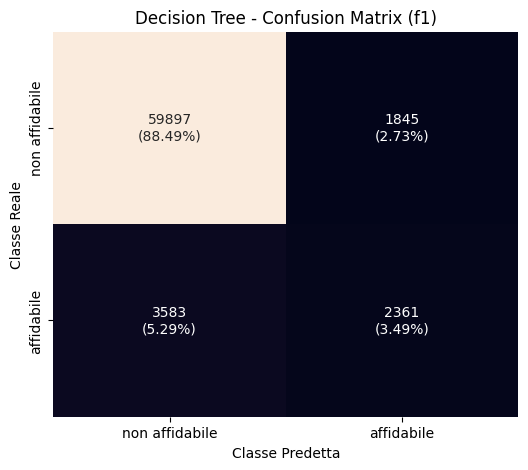

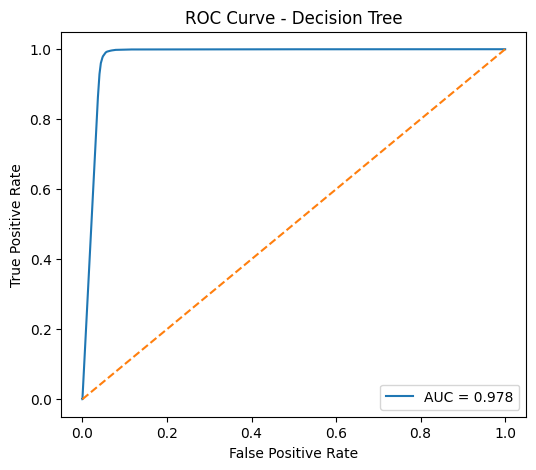

In [66]:
# Modello che usa come metrica F1

model_f1 = grid_search_evaluate(
    tree_unbal,
    param_grid,
    X_dt_train, X_dt_test,
    y_dt_train, y_dt_test,
    scoring="f1",
    model_name="Decision Tree"
)

### Interpretazione dei risultati

Dopo l’ottimizzazione del modello tramite GridSearchCV, si osserva che: la precision della classe 1 è diminuita a 0.56, il recall è calato a 0.40 e l’F1-score si riduce a 0.47. Questo comportamento indica che il modello è diventato **più conservativo**: classifica meno clienti come affidabili, riducendo il rischio di concedere credito a clienti non affidabili.

Infatti, il numero di clienti non affidabili predetti come affidabili (falsi positivi) è diminuito da 2493 a 1845, corrispondente al 2.73% rispetto al totale delle previsioni, mentre i clienti affidabili esclusi (falsi negativi) sono aumentati leggermente.

Questi risultati mostrano che il tuning ha avuto un effetto marginale sulle metriche globali, suggerendo che i limiti derivano principalmente dalla natura del modello (Decision Tree singolo) e dalla distribuzione sbilanciata dei dati, più che dalla scelta dei parametri.

Per quanto riguarda la ROC-AUC, le prestazioni del modelli rimangono eccellenti: AUC = 0.978.

In conclusione, il modello ottimizzato tende a ridurre il rischio creditizio a scapito della capacità di identificare tutti i clienti affidabili. **Per migliorare ulteriormente la precision della classe 1 senza ridurre troppo il recall, sarà necessario valutare strategie alternative, come ensemble di alberi (Random Forest, Gradient Boosting)**.

## B.4. Visualizzazione

La visualizzazione del Decision Tree può essere utile affinchè il team sia in grado di fornire una motivazione al cliente a cui è stata negata una carta di credito.

Per la visualizzazione si usa il modello non bilanciato non ottimizzato, poichè l'ottimizzazione ha peggiorato Precision, Recall e F1-score.

### Metodo 1_ testuale

In [67]:
# Modello addestrato
tree_model = model_unbal.named_steps["model"]

# Preprocessor dalla pipeline
preprocessor = model_unbal.named_steps["preprocessing"]

# OHE: nomi delle colonne trasformate
cat_ohe = preprocessor.named_transformers_["cat"]
feature_names_cat = cat_ohe.get_feature_names_out(cat_cols)

# Colonne binarie e numeriche passthrough
feature_names_bin = bin_cols
feature_names_num = num_cols

# Tutti i nomi finali
feature_names_all = list(feature_names_cat) + list(feature_names_bin) + list(feature_names_num)

# Mappatura leggibile
feature_names_readable = []
for f in feature_names_all:
    if "__" in f:
        col, val = f.split("__", 1)
        col_label = col_labels.get(col, col)
        val_label = value_labels.get(val, val)
        feature_names_readable.append(f"{col_label} = {val_label}")
    else:
        feature_names_readable.append(col_labels.get(f, f))

# Esportazione testo albero
tree_text = export_text(
    tree_model,
    feature_names=feature_names_readable,
    max_depth=5,
    decimals=2
)

print(tree_text)

|--- Annual Income <= 164783.87
|   |--- Annual Income <= 162736.70
|   |   |--- Annual Income <= 161242.74
|   |   |   |--- Annual Income <= 158150.72
|   |   |   |   |--- Annual Income <= 156890.59
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Annual Income >  156890.59
|   |   |   |   |   |--- class: 0
|   |   |   |--- Annual Income >  158150.72
|   |   |   |   |--- Annual Income <= 158151.29
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Annual Income >  158151.29
|   |   |   |   |   |--- class: 0
|   |   |--- Annual Income >  161242.74
|   |   |   |--- Annual Income <= 161242.98
|   |   |   |   |--- class: 1
|   |   |   |--- Annual Income >  161242.98
|   |   |   |   |--- Age <= 43.09
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age >  43.09
|   |   |   |   |   |--- class: 0
|   |--- Annual Income >  162736.70
|   |   |--- Years Employed (Employed Customers only) <= 13.59
|   |   |   |--- NAME_HOUSING_TYPE_Office apartment <= 0.50
|   |   |   |   |--- Ye

### Metodo 2: Grafico

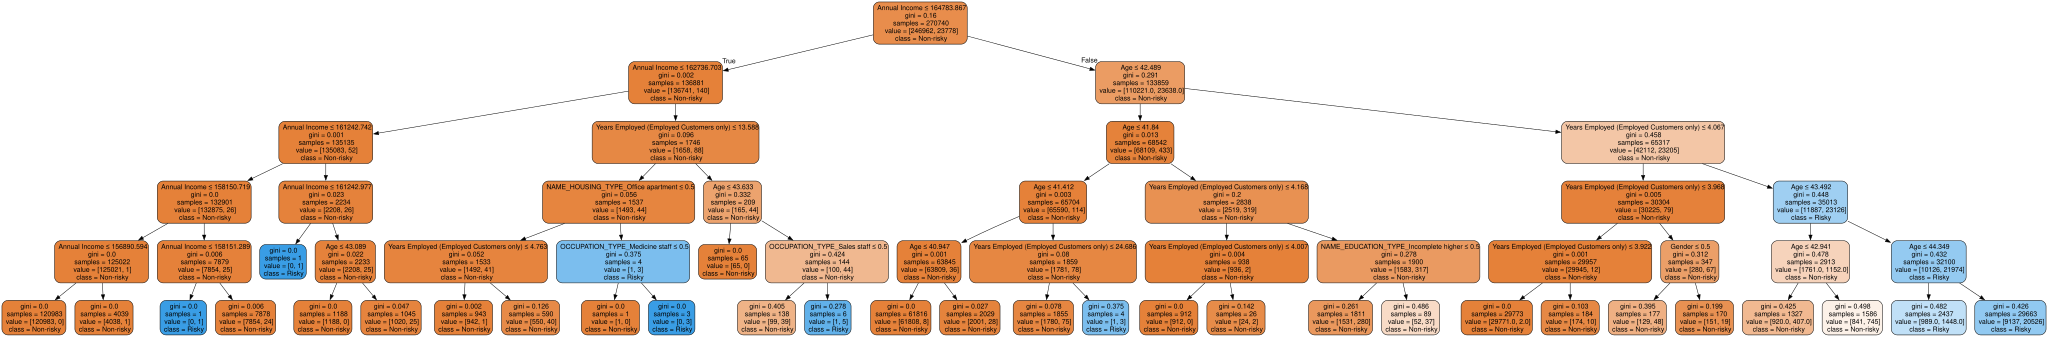

In [68]:
# Modello addestrato
tree_model = model_unbal.named_steps["model"]

# Preprocessor dalla pipeline
preprocessor = model_unbal.named_steps["preprocessing"]

# OHE: nomi delle colonne trasformate
feature_names_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)

# Colonne binarie e numeriche passthrough
feature_names_bin = bin_cols
feature_names_num = num_cols

# Tutti i nomi finali
feature_names_all = list(feature_names_cat) + list(feature_names_bin) + list(feature_names_num)

# Mappatura leggibile
feature_names_readable = []
for f in feature_names_all:
    if "__" in f:  # sklearn >=1.0 usa '__' tra colonna e valore
        col, val = f.split("__", 1)
        col_label = col_labels.get(col, col)
        val_label = value_labels.get(val, val)
        feature_names_readable.append(f"{col_label} = {val_label}")
    else:
        feature_names_readable.append(col_labels.get(f, f))

# Esporta l’albero in formato DOT
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=feature_names_readable,
    class_names=["Non-risky", "Risky"],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=5  # limita la profondità per leggibilità
)

# Visualizza il grafico con Graphviz
graph = graphviz.Source(dot_data)
graph.render("decision_tree_visual", format="png", cleanup=True)  # salva anche come PNG
graph  # mostra direttamente nel notebook

# Interpretazione del Decision Tree:
## Motivazioni del rifiuto della concessione della carta di credito

Gli alberi decisionali sono **intrinsecamente interpretabili**, il che permette di dare una motivazione al cliente a cui è stata rifiutata la carta di credito.

In un albero decisionale ogni previsione segue un percorso dai nodi radice fino a una foglia. Se il cliente viene rifiutato (classe 0) è possibile:

- Identificare quali feature hanno portato a classificare il cliente come non affidabile.
- Convertire queste feature in messaggi leggibili

In [69]:
def print_rejection_reasons(model, X_sample, feature_names):
    """
    Stampa le motivazioni del rifiuto per un singolo cliente
    usando un modello Decision Tree interpretabile.

    Parametri:
    - model: Pipeline con DecisionTreeClassifier addestrato
    - X_sample: dataframe 1xN con i dati del cliente
    - feature_names: lista dei nomi leggibili delle feature post-preprocessing
    """

    # Estrazione modello e preprocessore
    tree = model.named_steps["model"]
    preprocessor = model.named_steps["preprocessing"]

    # Trasforma il cliente tramite il preprocessore
    X_transformed = preprocessor.transform(X_sample)

    # Percorso dal nodo radice alla foglia
    node_indicator = tree.decision_path(X_transformed)
    leave_id = tree.apply(X_transformed)
    feature = tree.tree_.feature
    threshold = tree.tree_.threshold

    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]

    # Dizionario delle motivazioni
    explanations_dict = {}  # raggruppa per feature

    for node_id in node_index:
        if leave_id[0] == node_id:
            continue  # foglia raggiunta
            
        feat_idx = feature[node_id]
        feat_name = feature_names[feat_idx]
        value = X_transformed[0, feat_idx]
        thresh = threshold[node_id]
        
        # Per feature numeriche
        if "__" not in feat_name:  
            if feat_name not in explanations_dict:
                if value <= thresh:
                    explanations_dict[feat_name] = f"{feat_name} troppo basso ({value:.2f} <= {thresh:.2f})"
                else:
                    explanations_dict[feat_name] = f"{feat_name} troppo alto ({value:.2f} > {thresh:.2f})"
        
        # Per feature OHE
        else:
            col, val = feat_name.split(" = ")
            if col not in explanations_dict and value <= 0.5:
                explanations_dict[col] = f"{col} non corrisponde a {val}"

    if explanations_dict:
        print("Motivazioni del rifiuto:")
        for reason in explanations_dict.values():
            print("-", reason)
    else:
        print("Cliente approvato o nessuna motivazione disponibile")

### Esempio

In [70]:
# Esempio di utilizzo con il modello non bilanciato:

# Trova un cliente rifiutato dal modello
y_pred_test = model_unbal.predict(X_dt_test)
idx_rifiutato = np.where(y_pred_test == 0)[0][0]
X_rifiutato = X_dt_test.iloc[[idx_rifiutato]]

# Stampa motivazioni
print_rejection_reasons(model_unbal, X_rifiutato, feature_names_readable)

Motivazioni del rifiuto:
- Annual Income troppo alto (251458.04 > 164783.87)
- Age troppo basso (30.28 <= 42.49)


---------------------------------

# C. Random Forest

Il modello Random Forest Classifier è un modello ensemble basato su molti alberi decisionali. In particolare, è un **modello ensamble di tipo Bagging** (o Bootstrap Aggregating) che consente di addestrare in parallelo molti modelli indipendenti, ciascuno su un campione casuale dei dati.

Questo approccio consente di ridurre la varianza, migliorare la robustezza e l’accuratezza predittiva, riducendo il rischio di overfitting tipico dei singoli alberi.

La Random Forest mantiene anche un buon livello di interpretabilità, permettendo di valutare l’importanza relativa delle feature, e offre maggiore affidabilità nella classificazione dei clienti come affidabili o meno, risultando particolarmente indicata per dataset complessi e con variabili numeriche e categoriche miste come quello a disposizione.busto


## C.1. Preprocessamento

Si utilizza il dataframe *df_dec_tree* che ha già subito:

- Gestione dei dati mancanti, dei valori infiniti e dei duplicati
- Conversione delle variabili 0/1 da float a interi
- Rimozione delle variabili 'ID' e "FLAG_MOBIL"
- Gestione dei valori anomali molto alti di 'DAYS_EMPLOYED' e trasformazione delle variabili 'DAYS_EMPLOYED' e 'DAYS_BIRTH'rispettivamente in 'YEARS_EMPLOYED' e 'AGE'.

Si procede con il One-Hot Encoding delle variabili categoriche. Si utilizza *'drop=None'* per una interpretabilità maggiore

NOTA. NON è necessario eseguire Standardizzazione o Normalizzazione delle feature continue perchè gli alberi non usano le distanze, quindi ignorano la scala.

## C.2. Creazione e addestramento del modello

Come per i modelli Logistic Regression e Decision Tree, vengono di seguito utilizzati i**l modulo Pipeline di sklearn.pipeli**ne e l**a classe ColumnTransformer di sklearn.compo**se che consentono di rendere il flusso di lavoro automatico, con step ordinati, codice piulito ed evitare il data leakage o altri errori.

Si utilizza la funzione *train_and_evaluate* definita in precedenza per addestrare e valutare modelli.o.


===== Random Forest - balanced =====

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     61742
           1       0.70      0.75      0.72      5944

    accuracy                           0.95     67686
   macro avg       0.84      0.86      0.85     67686
weighted avg       0.95      0.95      0.95     67686



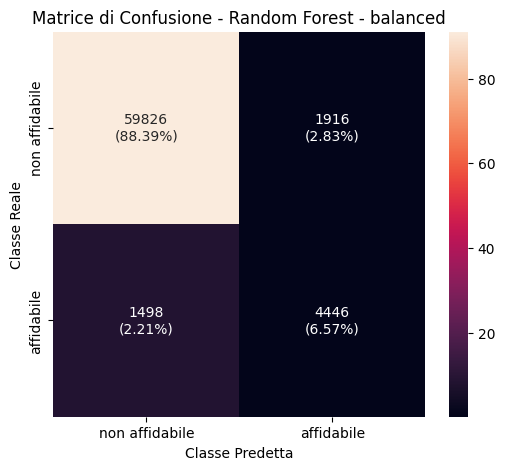

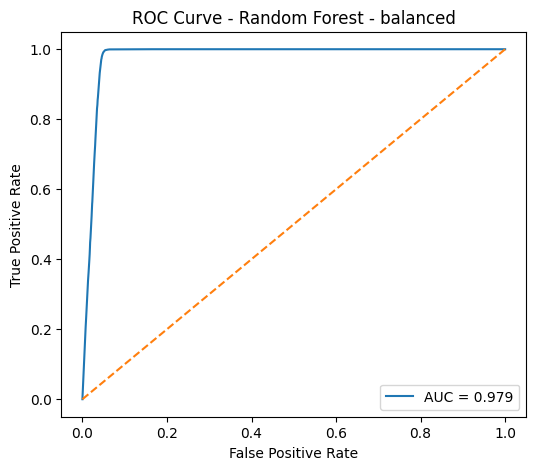


===== Random Forest - unbalanced =====

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     61742
           1       0.70      0.76      0.73      5944

    accuracy                           0.95     67686
   macro avg       0.84      0.87      0.85     67686
weighted avg       0.95      0.95      0.95     67686



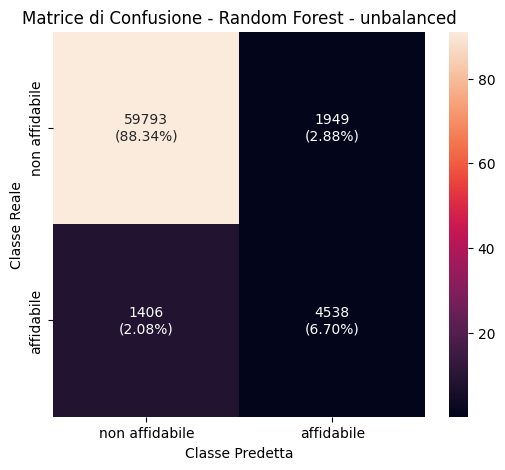

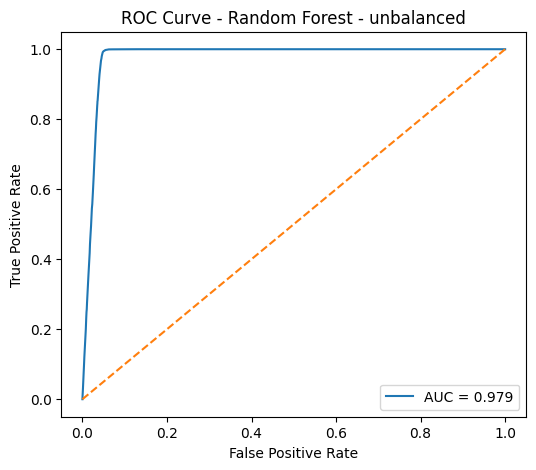

In [71]:
# 1. Preprocessamento 
preprocessor_rf = ColumnTransformer(transformers=[ 
    ("cat", OneHotEncoder(drop=None, handle_unknown='ignore'), cat_cols), # One-Hot Encoding
    ("bin", "passthrough", bin_cols), 
    ("num", "passthrough", num_cols) ]) 


# 2. Funzione per creare un modello Random Forest 
def create_rf_model(preprocessor, class_weight): 
    """ 
    Crea un modello di Random Forest integrato in una Pipeline con preprocessamento. 
    Parametri: 
    - preprocessor: ColumnTransformer per il preprocessing delle feature 
    - class_weight: 'balanced' o None, per gestire lo sbilanciamento delle classi 
    Output: 
    - Pipeline pronta da addestrare con due step: 
    1. preprocessing: applica One-Hot Encoding alle categoriche 
    2. model: RandomForestClassifier con random_state=0 e class_weight impostato 
    """ 
    return Pipeline(steps=[ 
        ("preprocessing", preprocessor), 
        ("model", RandomForestClassifier( 
            n_estimators=200, 
            class_weight=class_weight, 
            random_state=RANDOM_SEED, 
            n_jobs=-1 
        )) 
    ]) 


# 3. Creazione dei modelli 
# Modello bilanciato 
rf_bal = create_rf_model(preprocessor_rf, class_weight="balanced") 
# Modello NON bilanciato 
rf_unbal = create_rf_model(preprocessor_rf, class_weight=None) 


# 4. Split dei dati 
X_rf = df_dec_tree.drop("TARGET", axis=1) 
y_rf = df_dec_tree["TARGET"] 

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split( 
    X_rf, y_rf, test_size=0.2, stratify=y_rf, # mantiene proporzioni TARGET
    random_state=RANDOM_SEED ) 

# 6. Addestramento e confronto dei modelli 
model_rf_bal = train_and_evaluate( 
    rf_bal, X_rf_train, X_rf_test, y_rf_train, y_rf_test, 
    name="Random Forest - balanced" ) 

model_rf_unbal = train_and_evaluate( 
    rf_unbal, X_rf_train, X_rf_test, y_rf_train, y_rf_test,
    name="Random Forest - unbalanced" )

### Interpretazione dei risultati

Si considera che l’obiettivo del modello è ridurre il rischio di concedere credito a clienti non affidabili, cioè minimizzare i falsi positivi della classe 1 (clienti classificati come affidabili ma in realtà rischiosi), mantendendo un buon Recall.

- Entrambi i modelli hanno precision simile (0.70), quindi circa 1 cliente rischioso su 3 viene classificato erroneamente come affidabile.
- Il modello bilanciato ha falsi positivi leggermente più bassi (1916 vs 1949), riducendo marginalmente il rischio rispetto al modello non bilanciato.
- Il modello non bilanciato mostra un recall leggermente superiore (0.76 vs 0.75), catturando un po’ più di clienti affidabili, ma a costo di concedere credito a qualche cliente rischioso in più.

Considerando l’obiettivo di minimizzare il rischio creditizio, il modello bilanciato risulta leggermente preferibile, perché riduce il numero di clienti rischiosi erroneamente classificati come affidabili, anche se la differenza non è molto marcata.

Per quanto riguarda la ROC-AUC, le prestazioni di entrambi i modello sono eccellenti: AUC = 0.979.

Si procede quindi al tuning del modello bilanciato, con l’obiettivo di migliorare ulteriormente la precision della classe 1 senza compromettere eccessivamente il recall.

## C.3. Tuning e Pruning

Con **Tuning** si intende la scelta dei migliori iperparametri del modello al fine di ottimizzarne le prestazioni.

Con **Pruning** (= potatura) si intende la semplificazione di un albero decisionale per migliorare la capacità di generalizzazione ed evitare fenomeni di overfitting.

Nel presente caso, l’obiettivo è migliorare la precision della classe 1 (clienti affidabili) senza ridurre eccessivamente il recall, mantenendo quindi un buon equilibrio tra riduzione dei falsi positivi e capacità di identificare correttamente i clienti affidabili.

Gli iperparametri considerati sono:

- *'max_depth'* : rappresenta la profondità massima dell’albero. Aumentare la profondità consente al modello di catturare relazioni più complesse nei dati, ma può portare a overfitting se non controllato.
- *'min_samples_leaf'* : indica il numero minimo di osservazioni richieste in una foglia. Valori più elevati rendono il modello più stabile e meno sensibile al rumore, contribuendo a ridurre l’overfitting e, in alcuni casi, anche i falsi positivi.
- *'min_samples_split'* : definisce il numero minimo di campioni necessario per effettuare uno split di un nodo. Valori più alti limitano la crescita dell’albero, evitando suddivisioni basate su poche osservazioni e migliorando la generalizzazione.
- *'n_estimators'* : definisce il numero di alberi (di solito 100-500).
- *'max_features'* : definisce il numero di feature considerate ad ogni split.
- *'bootstrap'*  indica se usare il campionamento con ripetizione

Per la selezione degli iperparametri è stata utilizzata la tecnica di Grid Search, che esplora tutte le combinazioni dei valori specificati. Grid Search prova tutte le combinazioni dei valori forniti (in questo caso valori di max_depth, min_samples_leaf e min_samples_split), e per ogni combinazione: crea un modello, esegue k-fold cross-validation, allena il modello e calcola una metrica di performance. Infine Grid Search sceglie il modello con la performance migliore.

Come metrica è stato scelto l’**F1-score**, in quanto rappresenta un buon compromesso tra precision e recall ed è più adatto rispetto all’accuracy in presenza di dataset sbilanciati.

In [72]:
# Param grid per GridSearchCV
param_grid_rf = {
    "model__n_estimators": [100, 200],  # puoi aumentare se vuoi più precisione
    "model__max_depth": [4, 5, 6],
    "model__min_samples_leaf": [50, 100, 500],
    "model__min_samples_split": [100, 500],
    "model__max_features": ["sqrt", "log2"]
}


# Funzione per il tuning

def tune_and_evaluate(model, param_grid, X_train, y_train, X_test, y_test,
                      scorer, scorer_name="metric", sample_size=10000):
    """
    Esegue GridSearchCV su un modello e stampa i risultati.

    Parametri:
    - model: pipeline
    - param_grid: dizionario parametri
    - X_train, y_train: training set
    - X_test, y_test: test set
    - scorer: scorer sklearn (es. f1 o precision)
    - scorer_name: nome da stampare
    - sample_size: dimensione campione per tuning (default: 10'000)
    """

    # Campione stratificato
    X_sample, _, y_sample, _ = train_test_split(
        X_train, y_train,
        train_size=sample_size,
        stratify=y_train,
        random_state=RANDOM_SEED
    )

    
    # GridSearch
    grid = GridSearchCV(
        model,
        param_grid,
        cv=3,
        scoring=scorer,
        n_jobs=1,
        verbose=0
    )

    # Fit
    grid.fit(X_sample, y_sample)

    # Best model
    print(f"\n===== Tuning con {scorer_name} =====")
    print("Best parameters:", grid.best_params_)
    best_model = grid.best_estimator_


    # Predizione 
    y_pred = best_model.predict(X_test)

    
    # Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    labels = ["non affidabile", "affidabile"]
    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm / cm.sum() * 100

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.2f}%)"

    df_cm = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(6,5))
    sns.heatmap(df_cm, annot=annot, fmt="", cbar=False)
    plt.ylabel("Classe Reale")
    plt.xlabel("Classe Predetta")
    plt.title(f"Confusion Matrix - {scorer_name}")
    plt.show()

    
    # ROC CURVE   
    # Probabilità della classe positiva
    y_proba = best_model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")  # linea random
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {scorer_name}")
    plt.legend(loc="lower right")
    plt.show()


    return best_model


===== Tuning con F1-score =====
Best parameters: {'model__max_depth': 6, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 50, 'model__min_samples_split': 100, 'model__n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     61742
           1       0.63      0.99      0.77      5944

    accuracy                           0.95     67686
   macro avg       0.82      0.97      0.87     67686
weighted avg       0.97      0.95      0.95     67686



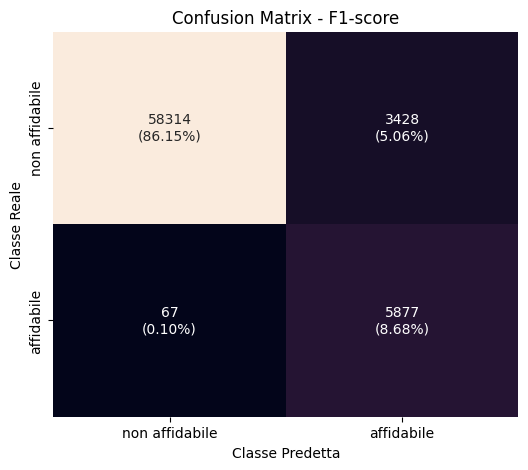

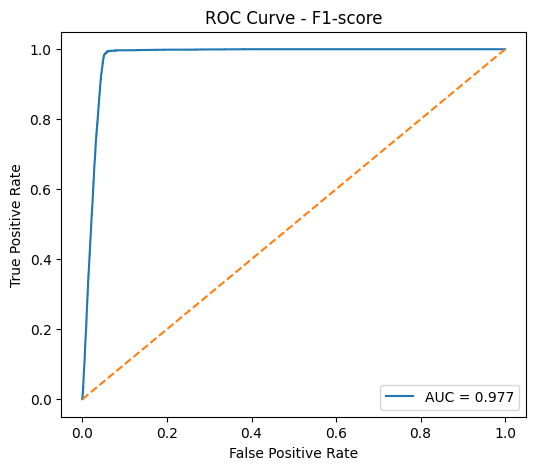

In [73]:
# Tunung del modello bilanciato con metrica F1-score

f1_scorer = make_scorer(f1_score, pos_label=1)

best_rf_f1 = tune_and_evaluate(
    rf_bal,
    param_grid_rf,
    X_rf_train, y_rf_train,
    X_rf_test, y_rf_test,
    scorer=f1_scorer,
    scorer_name="F1-score"
)

### Interpretazione dei risultati

Si considera che l’obiettivo del modello è ridurre il rischio di concedere credito a clienti non affidabili, cioè minimizzare i falsi positivi della classe 1 (clienti classificati come affidabili ma in realtà rischiosi), mantenendo un buon recall.

Il modello ottimizzato tramite Grid Search mostra un comportamento significativamente diverso rispetto ai modelli precedenti. In particolare, il **recall della classe 1 aumenta drasticamente (0.99)**, indicando che quasi tutti i clienti affidabili vengono correttamente identificati. Tuttavia, questo miglioramento avviene a scapito della **precision, che diminuisce a 0.63**, implicando che una quota maggiore di clienti non affidabili viene classificata erroneamente come affidabile.

Questo effetto è confermato dall’aumento dei falsi positivi, che passano da 1916 nel modello bilanciato a 3428 nel modello ottimizzato, evidenziando un incremento significativo del rischio creditizio. In altre parole, il modello tuned risulta **molto più permissivo**, approvando un numero maggiore di clienti ma includendo anche molti soggetti rischiosi.

Per quanto riguarda la ROC-AUC, le prestazioni rimangono eccellenti: AUC = 0.977.

Confrontando i modelli, il Random Forest bilanciato senza tuning risulta preferibile, in quanto mantiene una precision più elevata (0.70) e un numero significativamente inferiore di falsi positivi, garantendo quindi un migliore controllo del rischio.

Il tuning effettuato, basato sull’ottimizzazione dell’F1-score, ha privilegiato un equilibrio tra precision e recall, ma non è perfettamente allineato con l’obiettivo di business. Per questo motivo, sarebbe opportuno orientare ulteriormente l’ottimizzazione verso metriche che penalizzino maggiormente i falsi positivi, come la precision della classe 1.


===== Tuning con Precision classe 1 =====
Best parameters: {'model__max_depth': 6, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 50, 'model__min_samples_split': 100, 'model__n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     61742
           1       0.63      0.99      0.77      5944

    accuracy                           0.95     67686
   macro avg       0.82      0.97      0.87     67686
weighted avg       0.97      0.95      0.95     67686



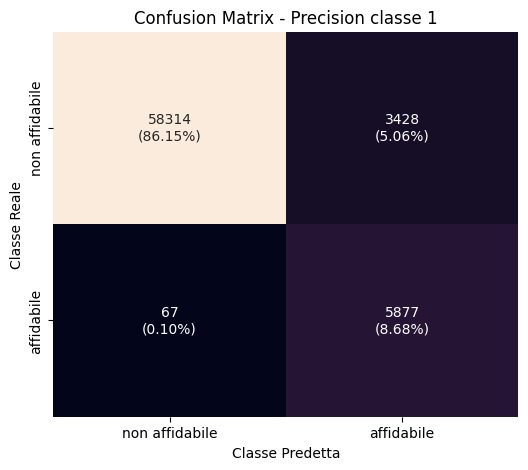

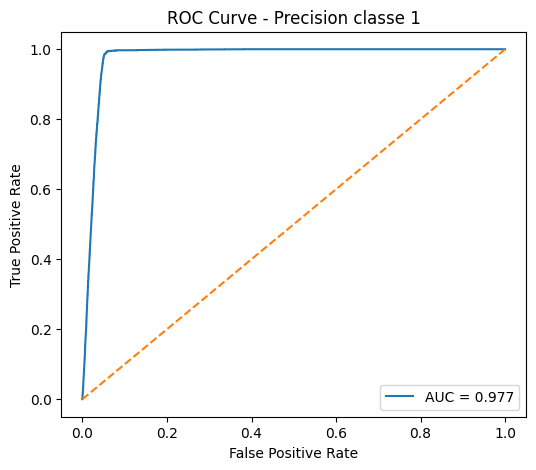

In [74]:
# Tunung del modello bilanciato con metrica Precision

precision_scorer = make_scorer(precision_score, pos_label=1)

best_rf_precision = tune_and_evaluate(
    rf_bal,
    param_grid_rf,
    X_rf_train, y_rf_train,
    X_rf_test, y_rf_test,
    scorer=precision_scorer,
    scorer_name="Precision classe 1"
)

### Interpretazione dei risultati

Il modello ottimizzato utilizzando la precision della classe 1 mostra un comportamento molto simile a quello ottenuto con l’ottimizzazione tramite F1-score:
- il recall della classe 1 risulta estremamente elevato (0.99), indicando che quasi tutti i clienti affidabili vengono correttamente identificati.
- Tuttavia, la precision scende a 0.63, segnalando un aumento significativo degli errori nella classificazione dei clienti non affidabili.
- il numero di falsi positivi (clienti non affidabili classificati come affidabili) rimane molto elevato, pari a 3428.

Questo implica che il modello tuned risulta fortemente sbilanciato verso l’approvazione dei clienti, diventando **eccessivamente permissivo** e aumentando sensibilmente il rischio creditizio.

Per quanto riguarda la ROC-AUC, le prestazioni rimangono eccellenti: AUC = 0.979.

Confrontando i modelli, il **Random Forest bilanciato senza tuning risulta ancora preferibile**, in quanto garantisce una precision più elevata (0.70) e un numero significativamente inferiore di falsi positivi, offrendo un miglior compromesso tra rischio e capacità predittiva.

Il tuning effettuato, non risulta allineato con l’obiettivo di business. Anche utilizzando la precision come metrica di ottimizzazione, il modello tende comunque a massimizzare il recall.

--------------------------------------------------------------

# D. Gradient Boosting

## D.1. Creazione e valutazione del modello

Il Gradient Boosting è un modello di machine learning supervisionato, in particolare un **modello ensamble di tipo Boosting** che consente di addestrare diversi modelli (di solito alberi decisionali) in sequenza: ogni nuovo modello corregge gli errori dei precedenti. Questo consente di ridurre la varianza e il bias (quindi la precisione) e catturare bene relazioni complesse tra le variabili. Con modelli di Gradient Boosting spesso l'accuratezza, ROC-AUC e F1-score migliorano. Lo svantaggio è che questo modello, non lavorando in parallelo ma in sequenza, è più lento da addestrare.


In [76]:
# Preprocessing
preprocessor_gb = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False), cat_cols),
    ("bin", "passthrough", bin_cols),
    ("num", "passthrough", num_cols)
])

In [85]:
# 1. Funzione per creare modelli Gradient Boosting

def create_gb_model(preprocessor):
    """
    Crea un modello Gradient Boosting integrato in una Pipeline con preprocessamento.
    
    Parametri:
    - preprocessor: ColumnTransformer per il preprocessing (numeriche, categoriche, binarie)
    - class_weight: non usato direttamente da GradientBoosting, ma rimane per compatibilità
    
    Output:
    - Pipeline pronto per addestramento
    """
    # GradientBoostingClassifier non gestisce class_weight, quindi sbilanciamento si può fare con 'sample_weight'
    return Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            subsample=0.8,
            random_state=RANDOM_SEED
        ))
    ])

In [86]:

def train_evaluate_gb(X_train, y_train, X_test, y_test, preprocessor, use_sample_weight=True, model_name="Gradient Boosting"):
    """
    Crea, addestra e valuta un modello Gradient Boosting con o senza sample_weight per gestire class imbalance.
    
    Parametri:
    - X_train, y_train: dati di training
    - X_test, y_test: dati di test
    - preprocessor: ColumnTransformer per il preprocessing
    - use_sample_weight: True se vogliamo bilanciare le classi con sample_weight
    - model_name: nome del modello per i grafici e le stampe
    
    Output:
    - model: modello addestrato
    - metrics: dizionario con metriche principali (precision, recall, f1, accuracy, auc)
    """
    
    # Creazione pipeline GB
    gb_model = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            subsample=0.8,
            random_state=RANDOM_SEED
        ))
    ])
    
    # Calcolo sample_weight se richiesto
    sample_weights = None
    if use_sample_weight:
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        print(f"Training con sample_weight per classi bilanciate")
    else:
        print(f"Training senza sample_weight (class_weight=None)")
    
    # Fit modello
    if use_sample_weight:
        gb_model.fit(X_train, y_train, model__sample_weight=sample_weights)
    else:
        gb_model.fit(X_train, y_train)
    
    # Predizioni
    y_pred = gb_model.predict(X_test)
    y_proba = gb_model.predict_proba(X_test)[:, 1]
    
    # Metriche
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
    metrics = {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n===== {model_name} =====")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    labels = ["non affidabile", "affidabile"]
    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm / cm.sum() * 100
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j]:.2f}%)"
    df_cm = pd.DataFrame(cm, index=labels, columns=labels)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(df_cm, annot=annot, fmt="")
    plt.ylabel("Classe Reale")
    plt.xlabel("Classe Predetta")
    plt.title(f"Matrice di Confusione - {model_name}")
    plt.show()
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()
    
    return gb_model, metrics

Training con sample_weight per classi bilanciate

===== Gradient Boosting - balanced =====

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     61742
           1       0.64      0.99      0.78      5944

    accuracy                           0.95     67686
   macro avg       0.82      0.97      0.87     67686
weighted avg       0.97      0.95      0.95     67686



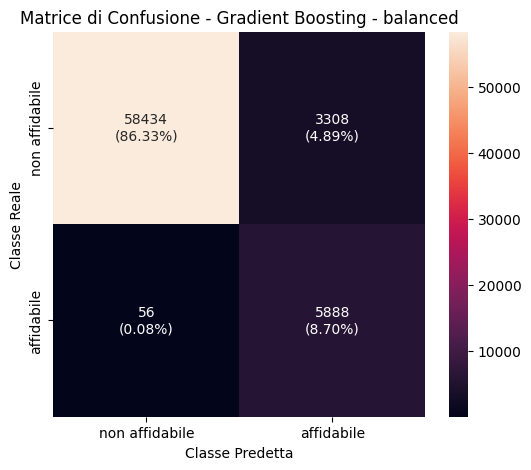

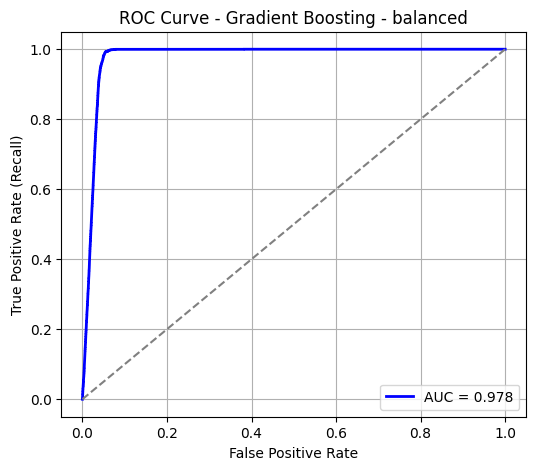

Training senza sample_weight (class_weight=None)

===== Gradient Boosting - unbalanced =====

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     61742
           1       0.69      0.93      0.79      5944

    accuracy                           0.96     67686
   macro avg       0.84      0.95      0.88     67686
weighted avg       0.97      0.96      0.96     67686



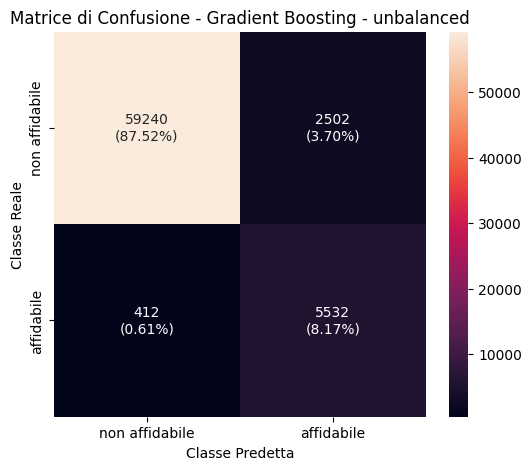

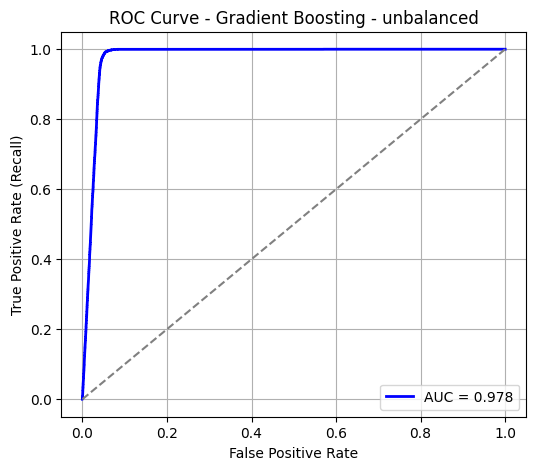

In [87]:
# Modello bilanciato con sample_weight
gb_bal_model, gb_bal_metrics = train_evaluate_gb(
    X_dt_train, y_dt_train,
    X_dt_test, y_dt_test,
    preprocessor_gb,
    use_sample_weight=True,
    model_name="Gradient Boosting - balanced"
)

# Modello non bilanciato
gb_unbal_model, gb_unbal_metrics = train_evaluate_gb(
    X_dt_train, y_dt_train,
    X_dt_test, y_dt_test,
    preprocessor_gb,
    use_sample_weight=False,
    model_name="Gradient Boosting - unbalanced"
)

### Interpretazione dei risultati

Si considera che l’obiettivo del modello è ridurre il rischio di concedere credito a clienti non affidabili, ovvero minimizzare i falsi positivi della classe 1 (clienti classificati come affidabili ma in realtà rischiosi), mantenendo al contempo un buon recall.

Il **modello bilanciato** mostra:
- Precision classe 1 non molto alta (= 0.64, significa che circa 36% dei clienti classificati come affidabili sono in realtà non affidabili).
- Recall classe 1 molto alto (=0.99, indica che il modello identifica quasi tutti i clienti affidabili).

Il modello di Gradient Boosting mostra prestazioni complessivamente bilanciate. In particolare:
- la **precision della classe 1 è pari a 0.69**, indicando che circa 3 clienti su 10 classificati come affidabili risultano in realtà non affidabili. Questo valore è in linea con quello osservato per il Random Forest non ottimizzato.
- il **recall della classe 1 è pari a 0.93**, evidenziando una buona capacità del modello di identificare i clienti affidabili, pur risultando meno estremo rispetto ai modelli ottimizzati (che raggiungevano valori prossimi a 0.99).

Il numero di falsi positivi è pari a 2502 (3.7%), migliore rispetto al modello bilanciato (3308, che corriscponde a 4.89% del totale). Questo valore è leggermente superiore rispetto al Random Forest bilanciato. Questo indica che il modello mantiene un **buon controllo del rischio, senza risultare eccessivamente permissivo**.

Per quanto riguarda la ROC-AUC, entrambi i modelli presentano prestazioni eccellenti (AUC = 0.978), molto simili a quelle degli altri modelli analizzati. Questo conferma una forte capacità discriminante, ma, come già osservato, tale metrica non è sufficiente da sola per guidare la scelta finale.

Nel complesso, il Gradient Boosting, in particolare il **modello non bilanciato, rappresenta un buon compromesso tra precision e recall**, offrendo prestazioni stabili e bilanciate.

## D.2. Tuning e Pruning

L’obiettivo è migliorare la precision della classe 1 (clienti affidabili) senza ridurre eccessivamente il recall, mantenendo quindi un buon equilibrio tra riduzione dei falsi positivi e capacità di identificare correttamente i clienti affidabili.

Gli iperparametri considerati sono:

- *'n_estimators'* : rappresenta il numero di alberi costruiti in sequenza. Un numero maggiore può migliorare le prestazioni del modello, ma aumenta il tempo di addestramento e, se combinato con un learning rate elevato, può portare a overfitting.
- *'learning_rate'* : controlla il contributo di ciascun albero al modello finale. Valori più bassi rendono l’apprendimento più graduale e robusto, migliorando la generalizzazione, ma richiedono un numero maggiore di alberi per ottenere buone performance.
- *'max_depth'* : indica la profondità massima di ciascun albero debole. Valori più bassi producono modelli più semplici e meno soggetti a overfitting, mentre profondità maggiori permettono di catturare relazioni più complesse ma aumentano il rischio di adattamento eccessivo ai dati.
- *'min_samples_leaf'* : definisce il numero minimo di osservazioni in una foglia. Valori più elevati rendono il modello più stabile e meno sensibile al rumore, contribuendo a migliorare la capacità di generalizzazione e, in alcuni casi, a ridurre i falsi positivi.
- *'subsample'* : indica la frazione di osservazioni utilizzate per addestrare ciascun albero. Valori inferiori a 1 introducono una componente di casualità (stochastic gradient boosting), che può ridurre l’overfitting e migliorare la robustezza del modello, mentre valori pari a 1 utilizzano l’intero dataset rendendo il modello più deterministico.

Come metrica è stato scelto l’**F1-score**, in quanto rappresenta un buon compromesso tra precision e recall ed è più adatto rispetto all’accuracy in presenza di dataset sbilanciati.



===== Tuning con Precision classe 1 =====
Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_samples_leaf': 100, 'model__n_estimators': 200, 'model__subsample': 1.0}

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     61742
           1       0.69      0.89      0.78      5944

    accuracy                           0.95     67686
   macro avg       0.84      0.92      0.88     67686
weighted avg       0.96      0.95      0.96     67686



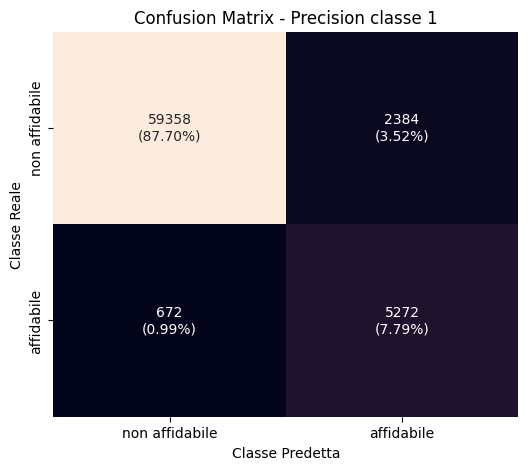

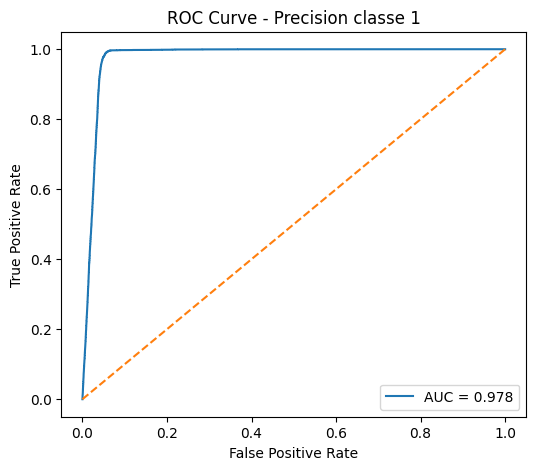

In [93]:
param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__min_samples_leaf": [50, 100],
    "model__subsample": [0.8, 1.0]
}

precision_scorer = make_scorer(precision_score, pos_label=1)

best_gb_precision = tune_and_evaluate(
    gb_unbal_model,
    param_grid_gb,
    X_dt_train, y_dt_train,
    X_dt_test, y_dt_test,
    scorer=precision_scorer,
    scorer_name="Precision classe 1"
)

### Interpretazione dei risultati

Si considera che l’obiettivo del modello è ridurre il rischio di concedere credito a clienti non affidabili, ovvero minimizzare i falsi positivi della classe 1 (clienti classificati come affidabili ma in realtà rischiosi), mantenendo al contempo un buon livello di recall.

Il modello di Gradient Boosting ottimizzato sulla precision della classe 1 mostra un comportamento più conservativo rispetto alla versione base. In particolare, la **precision della classe 1 rimane pari a 0.69**, indicando che circa 3 clienti su 10 classificati come affidabili risultano in realtà non affidabili, in linea con il modello non ottimizzato.

Il **recall della classe 1 diminuisce a 0.89**, evidenziando una riduzione della capacità di intercettare tutti i clienti affidabili. Questo implica che una quota maggiore di clienti affidabili viene esclusa (falsi negativi), rendendo il modello più selettivo.

Il **numero di falsi positivi si riduce** a 2384 (3.52%), valore inferiore rispetto al modello base (2502) e significativamente più contenuto rispetto ai modelli ottimizzati della Random Forest. Questo rappresenta un miglioramento rilevante in termini di contenimento del rischio creditizio.

Per quanto riguarda la ROC-AUC, le prestazioni rimangono eccellenti (AUC = 0.978), in linea con gli altri modelli. 

Nel complesso, il tuning ha prodotto un effetto coerente con l’obiettivo di business: il modello diventa più conservativo, riducendo il numero di clienti non affidabili erroneamente approvati, a fronte di una moderata perdita in recall.